# Function 6

The function is described by 5 input features, each of which is normalised to lie between 0 and 1. The optimisation goal is to maximise the output. The function describes the combined score based on flavour, consistency, calories, waste and cost of cake recipes judged by an expert taster. Negative points are assigned to the factors that contribute to the score, and therefore the total score is negative. It is unknown how the factors that contribute to the scores are combined, and whether they are given different weights.

The five input features are the ingredients. The initial data set consists of 20 data points.

## Summary

A promising region is found to lie in the space around (0.55, 0.4, 0.4, 0.8, 0.15). An early suspicion that the output in this region may be insensitive to changes in `x0` and `x2` has been refuted. Although difficult to state with a high degree of certainty given the relatively small number of data points relative to the number of dimensions, it appears that the output is sensitive to changes in all features within the promising region.

Only one promising region was found. Given that the features are ingredients for a cake recipe, multiple local maxima were not expected. Therefore, a policy of exploitation was conducted, followed by short interlude where the domain was explored, before returning to exploit the promising region again. The best observed point was found during the initial period of exploitation in week 2. This was done using Bayesian Optimisation with a Gaussian Process surrogate model and candidate points were selected using a grid search and were assessed using a Probability of Improvement acquisition function.

After a brief period of exploration, week 11 saw a return to Bayesian Optimisation with a Gaussian Process surrogate model. However, rather than use a grid with a relatively poor resolution (for computational reasons), candidates were sampled randomly across the domain. A decision tree model was used to split the domain into regions. Candidates were generated according to a softmax function which favoured generation in high-value areas that had been identified by the decision tree model. This was the most promising method, tackling the problem of poor grid resolution at higher dimensions.

## Week 1 - Initial exploitation

In [1]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.utils import construct_meshgrid

seed_input = "function 6"  # input string to create random seed
n_dimensions = 5  # number of features
grd_res = 21  # axis resolution

In [2]:
X, y = get_current_weeks_points(function_id=6, week=1)

print(f"Mean = {y.mean()}")
print(f"Standard deviation = {y.std()}")

print(f"Minimum = {y.min()}")
quantiles = [0.25, 0.5, 0.75]
for quantile in quantiles:
    print(f"{quantile * 100}% quantile = {np.quantile(y, quantile)}")
print(f"Maximum = {y.max()}\n")

max_idx = np.argmax(y)
x_best = X[max_idx]
y_max = y[max_idx]
mask = np.ones(len(X), dtype=bool)
mask[max_idx] = False
print(f"Minimum distance between best point and nearest neighbour = {np.min(np.linalg.norm(X[mask] - x_best, axis=1))}")

Mean = -1.4953899396939465
Standard deviation = 0.44899959039781934
Minimum = -2.5711696316081234
25.0% quantile = -1.7136389021860792
50.0% quantile = -1.446369908975912
75.0% quantile = -1.2278285965980067
Maximum = -0.7142649478202404

Minimum distance between best point and nearest neighbour = 0.5117612408935975


Initial exploratory data analysis indicates that the values are fairly well spread out, although the difference between the 25% and 75% quantiles is approximately the same as that between the 75% quantile and current maximum. The Euclidean distance between the best observed point and its nearest neighbour is relatively large, which suggests that the current maximum may lie in a relatively isolated region in the domain.

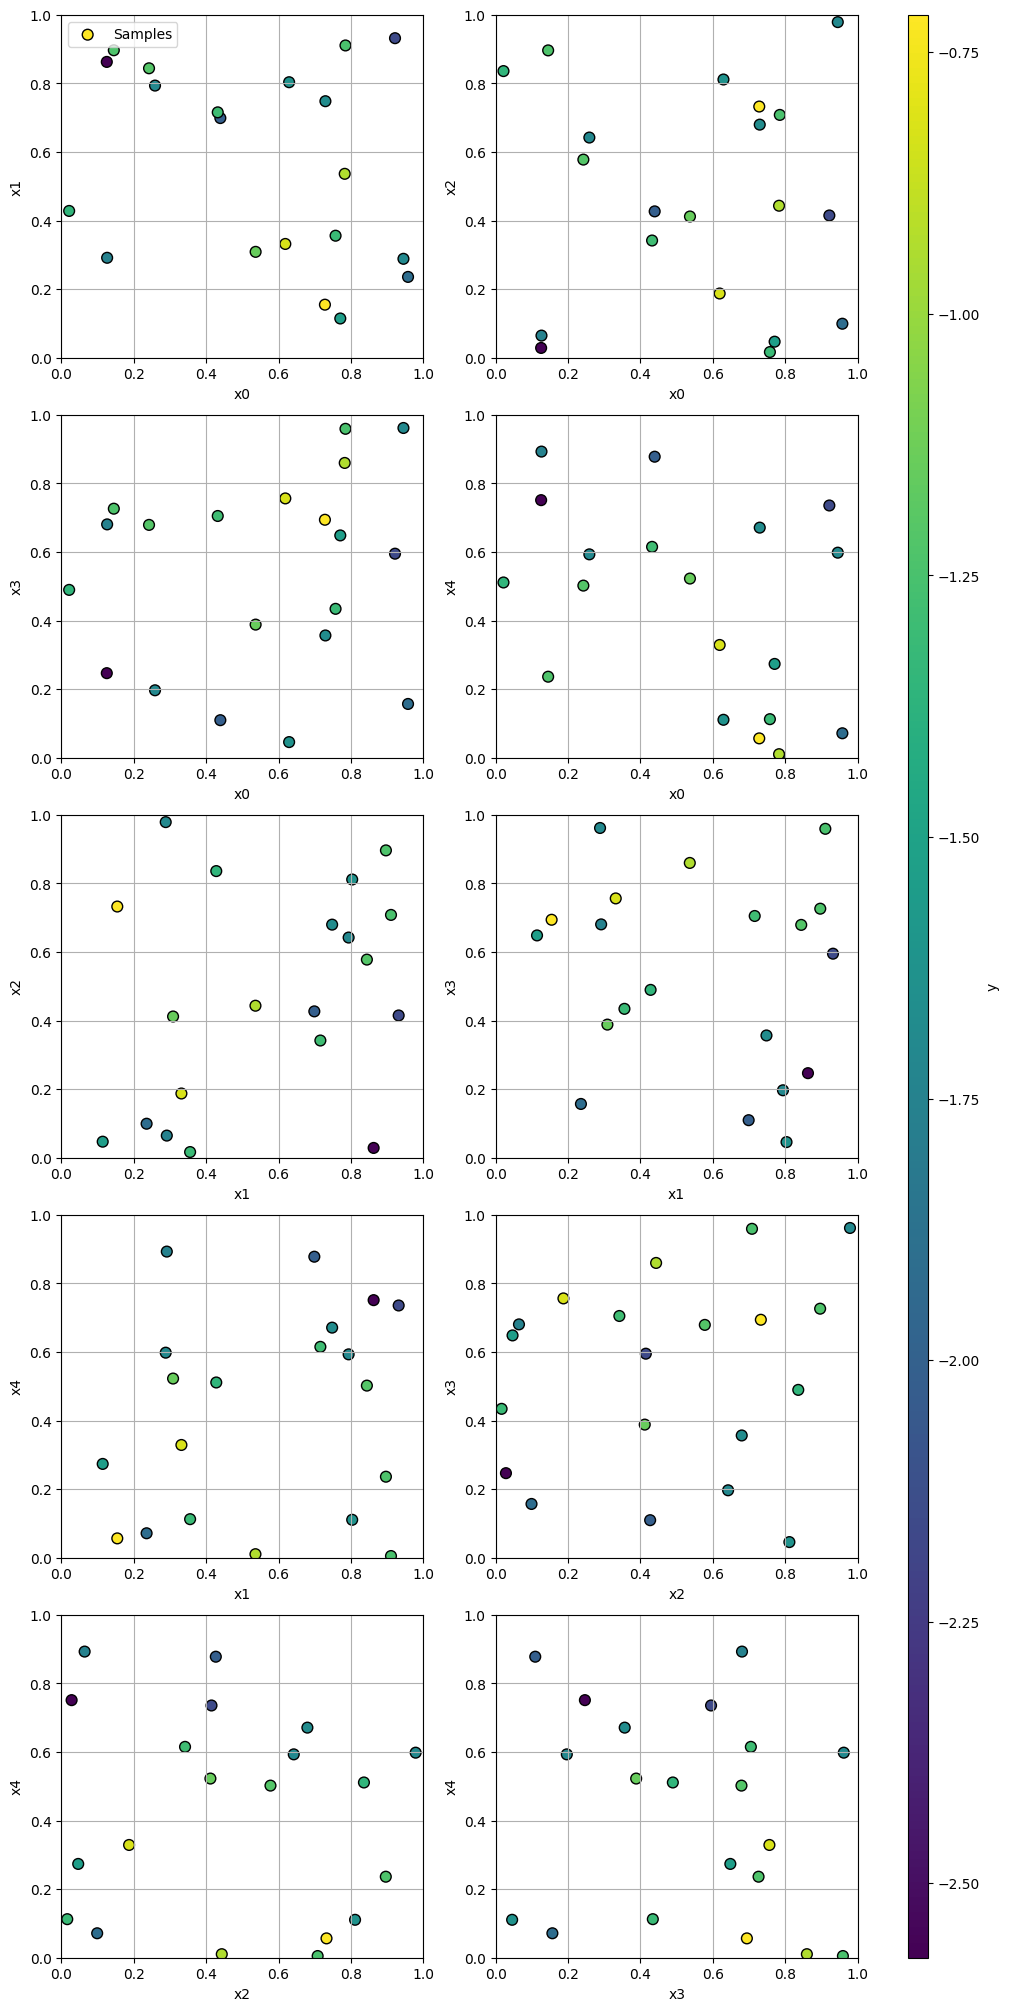

In [3]:
fig, axs = plot_2d_array(X, y)

As there is likely to be an optimal combination of ingredients when baking a cake, it is reasonable to assume at this initial stage that there is only one maximum. For now, we can work under the assumption that the best observed point lies in the same region as the global maximum and can follow a policy of exploitation around it. Once we are satisfied that we are close to the maximum in this region, we can challenge our assumption of there being a single global maximum and explore other regions.

We fit a Gaussian Process surrogate model to the data and perform a grid search to find candidate points to query. For computational reasons, a fairly low grid resolution is used. We assess the candidate points using the exploitative Probability of Improvement (PI) acquisition function. Given that the outputs are fairly well spread out and working under the assumption that there is a single maximum within the domain, it is reasonable to assume that the peak is fairly smooth and therefore a Radial Basis Function (RBF) kernel with initial length scale 0.2 is used:

In [4]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=n_dimensions,
    seed_input=seed_input,
    initial_length_scale=0.2,
    length_scale_bounds=(1e-2, 100),
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: {length_scales}")

# Perform grid search to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([x_grid.ravel() for x_grid in X_grid])
y_mean, y_std = model.predict(X_pred, return_std=True)

# Use Probability of Improvement (PI) acquisition function for exploitation
acq = acquisition.prob_improv(y_mean, y_std, y_max)
max_idx = np.argmax(acq)
x_next = X_pred[max_idx]
print(f"Proposed point using Probability of Improvement acquisition function = {x_next}")
print(f"Distance between proposed point and best point = {np.linalg.norm(x_next - x_best)}")
print(f"Distance between proposed point and nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}")

Length scales: [0.30835873 0.59252447 0.60001336 0.63308527 0.44929954]
Proposed point using Probability of Improvement acquisition function = [0.55 0.4  0.35 0.8  0.25]
Distance between proposed point and best point = 0.535713538399416
Distance between proposed point and nearest neighbour = 0.20974106776744847


The comparable length scales suggest that the model believes there are no single feature is significantly more sensitive than the others. Interestingly, the distance between the best and proposed points is large enough to imply that it lies in another region. The distance between the proposed point and its nearest neighbour is around half this. This relatively large distance between the best and proposed points may be in part a result of the relatively poor grid resolution. Another reason is our relatively large initial guess for the length scales, as we assume that the underlying function is smooth.

Querying the proposed point will give us an idea of the extent of this region.

## Week 2 - A modest improvement

In [5]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.utils import grid_search

seed_input = "function 6"  # input string to create random seed
n_dimensions = 5  # number of features
grd_res = 21  # axis resolution

In [6]:
X, y = get_current_weeks_points(function_id=6, week=2)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.55 0.4  0.35 0.8  0.25] yields -0.7038945222208884


Last week's query yields an output that is slightly higher than that of the best observed point in the initial dataset. The relatively large distance between last week's query and the best observed point in the initial dataset may indicate the presence of a relatively large promising region to investigate.

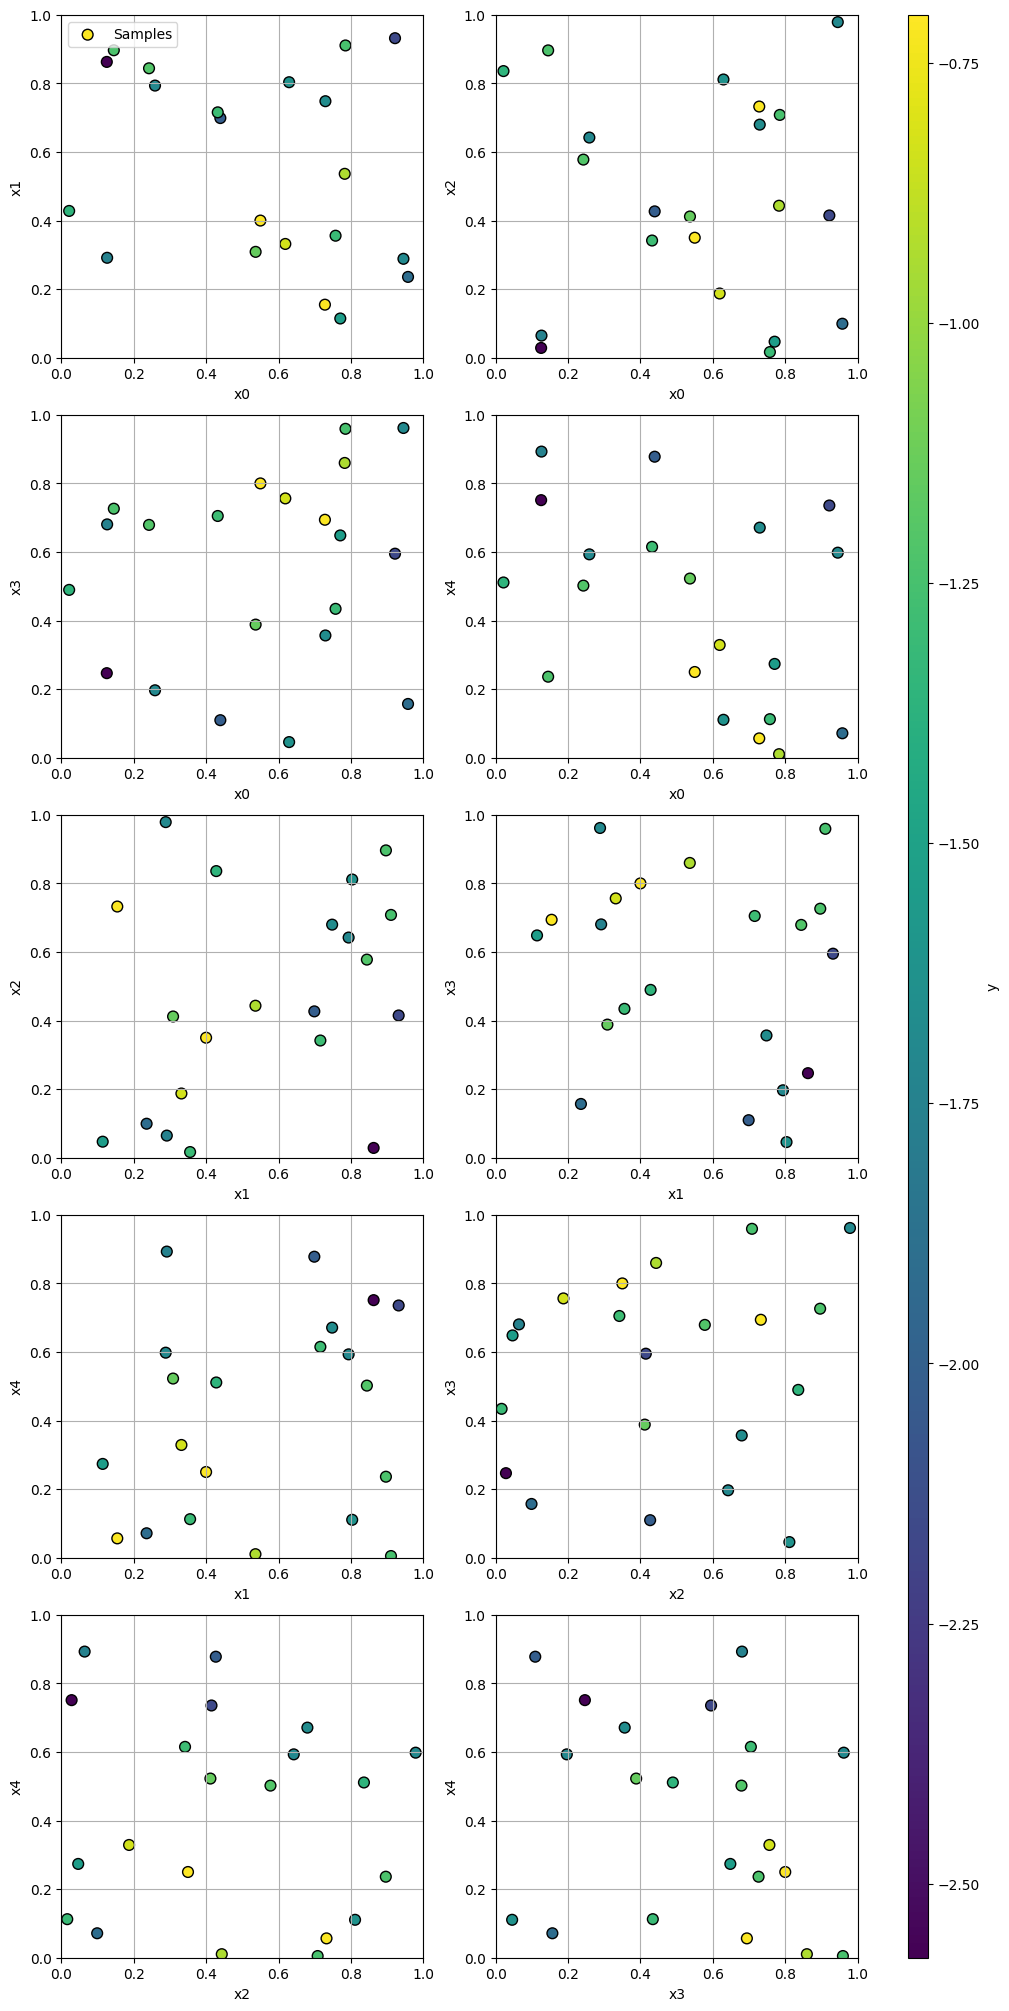

In [7]:
fig, axs = plot_2d_array(X, y)

For the time being we can continue with our policy of exploitation by building a Gaussian Process surrogate model as we did last week, and perform a grid search using the Probability of Improvement (PI) function to find the next point to query. As mentioned in last week's analysis, a relatively coarse grid resolution is used to limit the computational cost. Through a recursive process, we can identify a promising candidate point on the grid, zoom in on this point and draw another grid around it with a higher resolution. We can repeat this process until we achieve a resolution equivalent to 6 decimal places, which is the maximum precision of inputs we can submit in our queries.

Although this helps us to direct our attention to a promising region, given the relatively poor initial grid resolution across the whole domain, it is possible that other promising regions may be overlooked.

In [8]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=n_dimensions,
    seed_input=seed_input,
    initial_length_scale=0.2,
    length_scale_bounds=(1e-2, 100),
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: {length_scales}")

# Perform grid search with Probability of Improvement (PI) acquisition function
max_idx = np.argmax(y)
x_best = X[max_idx]
y_max = y[max_idx]
x_next = grid_search(model, acq_func=acquisition.prob_improv, y_max=y_max, n_dimensions=n_dimensions, grd_res=grd_res)
print(f"Proposed point using Probability of Improvement acquisition function = {x_next}")
print(f"Distance between proposed point and best point = {np.linalg.norm(x_next - x_best)}")

Length scales: [0.2225788  0.63015848 0.53507635 0.66563837 0.77221674]
Proposed point using Probability of Improvement acquisition function = [0.59781006 0.34781006 0.39781006 0.84781006 0.09781006]
Distance between proposed point and best point = 0.18095019447701502


The length scale for feature `x0` is around a third of the value of the others, implying that the model believes the output of the underlying function is more senstive to changes along this dimension.

We obtain a proposed point that appears to lie within the same region as the best point, yet is far enough away to provide more information about this region. Although it is too early to state this with certainty, the smaller distance between proposed and best points compared with that from last week's analysis indicates that the optimiser may be beginnning to converge.

As a side note, during the original analysis, an unknown random seed was used during the creation of the Gaussian Process surrogate model. Therefore, the optimiser used different random initialisations when tuning the model's hyperparameters. As a result, the point (0.5687, 0.374362, 0.38575, 0.832375, 0.152625) was found to maximise the PI acquisition function and was submitted as this week's query. The submitted point lies very close to the proposed point above, and therefore should not affect the general upward trend on the output.

## Week 3 - A new maximum

In [9]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.utils import grid_search

seed_input = "function 6"  # input string to create random seed
n_dimensions = 5  # number of features
grd_res = 21  # axis resolution

In [10]:
X, y = get_current_weeks_points(function_id=6, week=3)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.5687   0.374362 0.38575  0.832375 0.152625] yields -0.45127050312758443


Last week's query yields a new maximum output. The model appears to be converging to a local maximum in this region.

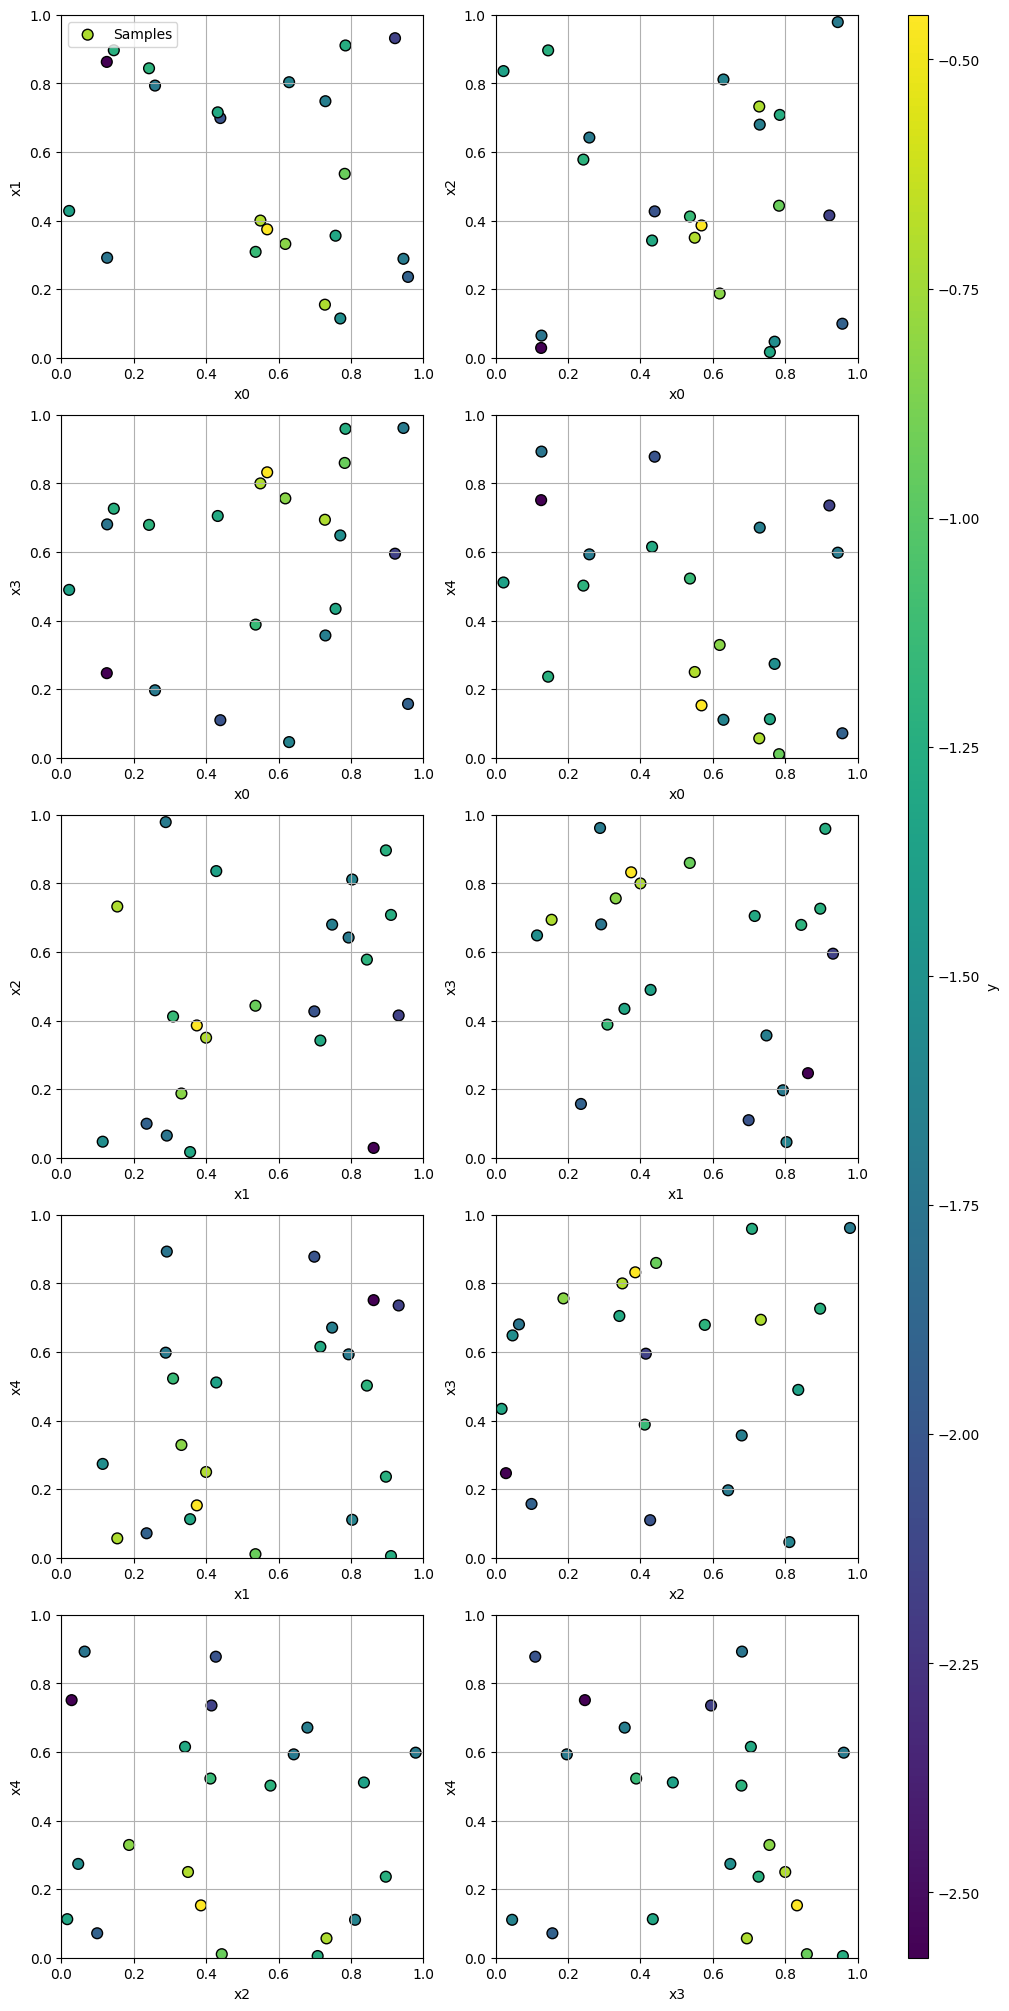

In [11]:
fig, axs = plot_2d_array(X, y)

Given the continued improvements in output with each query, we should continue with our policy of exploitation by building a Gaussian Process surrogate model and conducting a recursive grid search using the Probability of Improvement (PI) acquisition function to assess candidate points:

In [12]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=n_dimensions,
    seed_input=seed_input,
    initial_length_scale=0.2,
    length_scale_bounds=(1e-2, 100),
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: {length_scales}")

# Perform grid search with Probability of Improvement (PI) acquisition function
max_idx = np.argmax(y)
x_best = X[max_idx]
y_max = y[max_idx]
x_next = grid_search(model, acq_func=acquisition.prob_improv, y_max=y_max, n_dimensions=n_dimensions, grd_res=grd_res)
print(f"Proposed point using Probability of Improvement acquisition function = {x_next}")
print(f"Distance between proposed point and best point = {np.linalg.norm(x_next - x_best)}")

/home/chagani/projects/github/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Length scales: [100.           0.20137384   0.8146181    0.49179394   0.26627489]
Proposed point using Probability of Improvement acquisition function = [0.55354133 0.35354133 0.45354133 0.85354133 0.10354133]
Distance between proposed point and best point = 0.09008978948981726


Interestingly, the length scales have changed significantly compared with those from last week. Perhaps the most pronounced change is in the length scale for `x0`. Last week, the model believed that changes in output were most sensitive to changes in `x0`. This week, the length scale for `x0` has hit the upper boundary, suggesting that the output is relatively insensitive to changes in this dimension. Caution in reading too much into this change would be prudent, as this variation may be a result of the relatively few data points we have. The length scales may indicate that, according to the model, the output is more sensitive to changes in `x1` and `x4`.

The distance between the best observed and proposed points is getting smaller with each iteration, indicating that the model appears to be converging.

As before, in the original analysis an unknown random seed was used to initialise the Gaussian Process surrogate model. Therefore, the point (0.572375, 0.3713, 0.388325, 0.835025, 0.14262) was submitted. The submitted point lies close enough to the proposed point that this discrepancy is unlikely to affect the upward trend in the output.

## Week 4 - Reaching the point of diminishing returns

In [13]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.utils import grid_search

seed_input = "function 6"  # input string to create random seed
n_dimensions = 5  # number of features
grd_res = 21  # axis resolution

In [14]:
X, y = get_current_weeks_points(function_id=6, week=4)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.572375 0.3713   0.388325 0.835025 0.142625] yields -0.5565950270829171


Last week's query yields a slightly lower output than that of the best observed point. However, it yields a relatively high value providing further evidence that this is a promising region to continue to query.

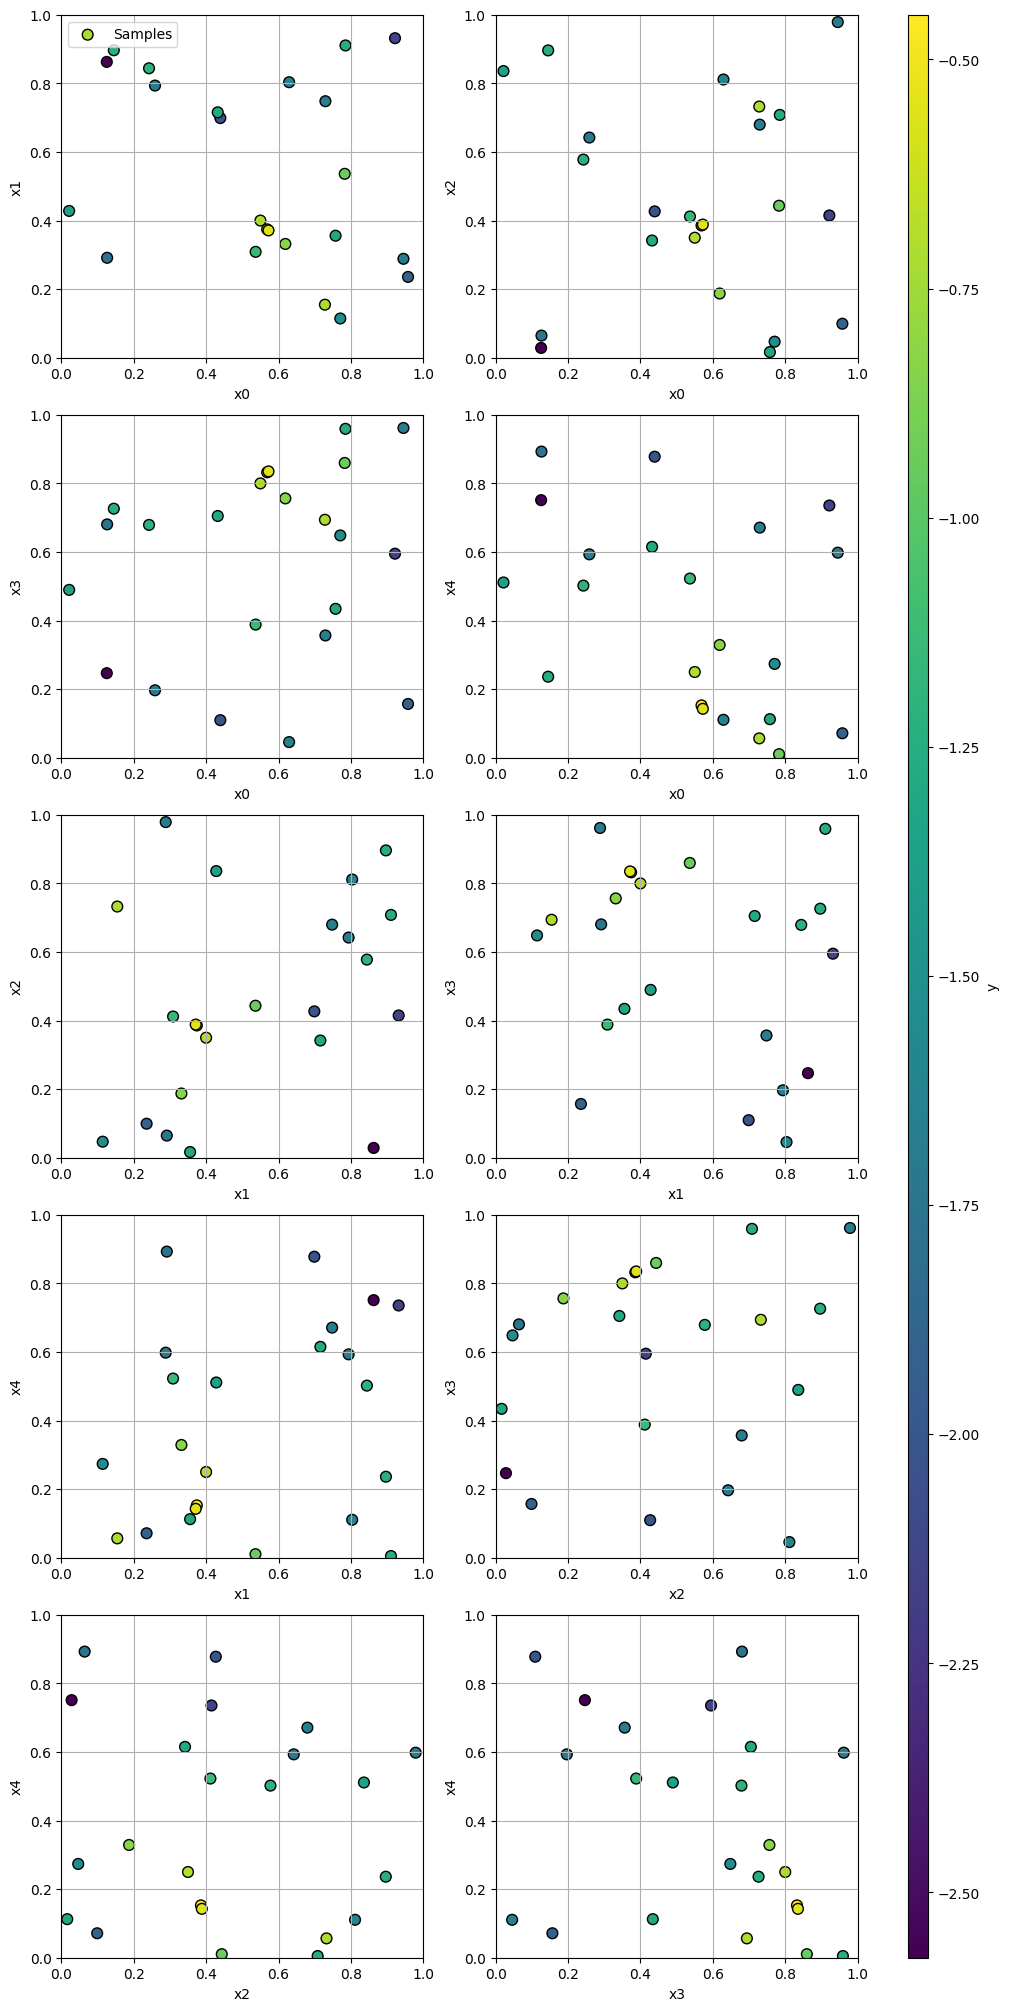

In [15]:
fig, axs = plot_2d_array(X, y)

At this stage there is no reason to change our methodology, so we continue to train a Gaussian Process surrogate model and peform a recursive grid search. We continue to use the Probability of Improvement (PI) acquisition function to assess the candidate points:

In [16]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=n_dimensions,
    seed_input=seed_input,
    initial_length_scale=0.2,
    length_scale_bounds=(1e-2, 100),
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: {length_scales}")

# Perform grid search with Probability of Improvement (PI) acquisition function
max_idx = np.argmax(y)
x_best = X[max_idx]
y_max = y[max_idx]
x_next = grid_search(model, acq_func=acquisition.prob_improv, y_max=y_max, n_dimensions=n_dimensions, grd_res=grd_res)
print(f"Proposed point using Probability of Improvement acquisition function = {x_next}")
print(f"Distance between proposed point and best point = {np.linalg.norm(x_next - x_best)}")

/home/chagani/projects/github/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Length scales: [1.00000000e+02 3.82244285e-01 7.27984492e-01 4.58332410e-01
 6.33150646e-02]
Proposed point using Probability of Improvement acquisition function = [0.52368422 0.37368422 0.37368422 0.82368422 0.17368422]
Distance between proposed point and best point = 0.05187950847144999


Again, the length scale for `x0` hits the upper boundary, indicating the model has not found any strong variation in output along this dimension. In contrast, the length scale for `x4` is approximately an order of magnitude smaller than the others, indicating that the model believes the output to be more sensitive to changes along this dimension. Given the relatively few data points available, these effects are likely local rather than global.

The Euclidean distances between the proposed and best points have been decreasing, which suggests that we are converging on the local maximum. We appear to be reaching the point of diminishing returns given how close the proposed point lies to the best observed point. In future, it may be worth adopting a policy of exploration to investigate whether our initial assumption of the presence of only one peak is justified.

Again, an unknown random seed was used in the original analysis, so the point (0.55817, 0.374441, 0.378815, 0.826076, 0.175959) was submitted as this week's query. This is very close to the proposed point above.

## Week 5 - Adopting a more exploratory policy

In [17]:
import numpy as np

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.utils import grid_search

seed_input = "function 6"  # input string to create random seed
n_dimensions = 5  # number of features
grd_res = 21  # axis resolution

In [18]:
X, y = get_current_weeks_points(function_id=6, week=5)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.55817  0.374441 0.378815 0.826076 0.175959] yields -0.46158995973961586


Last week's query yields a relatively high output value that is just a little shy of the current maximum.

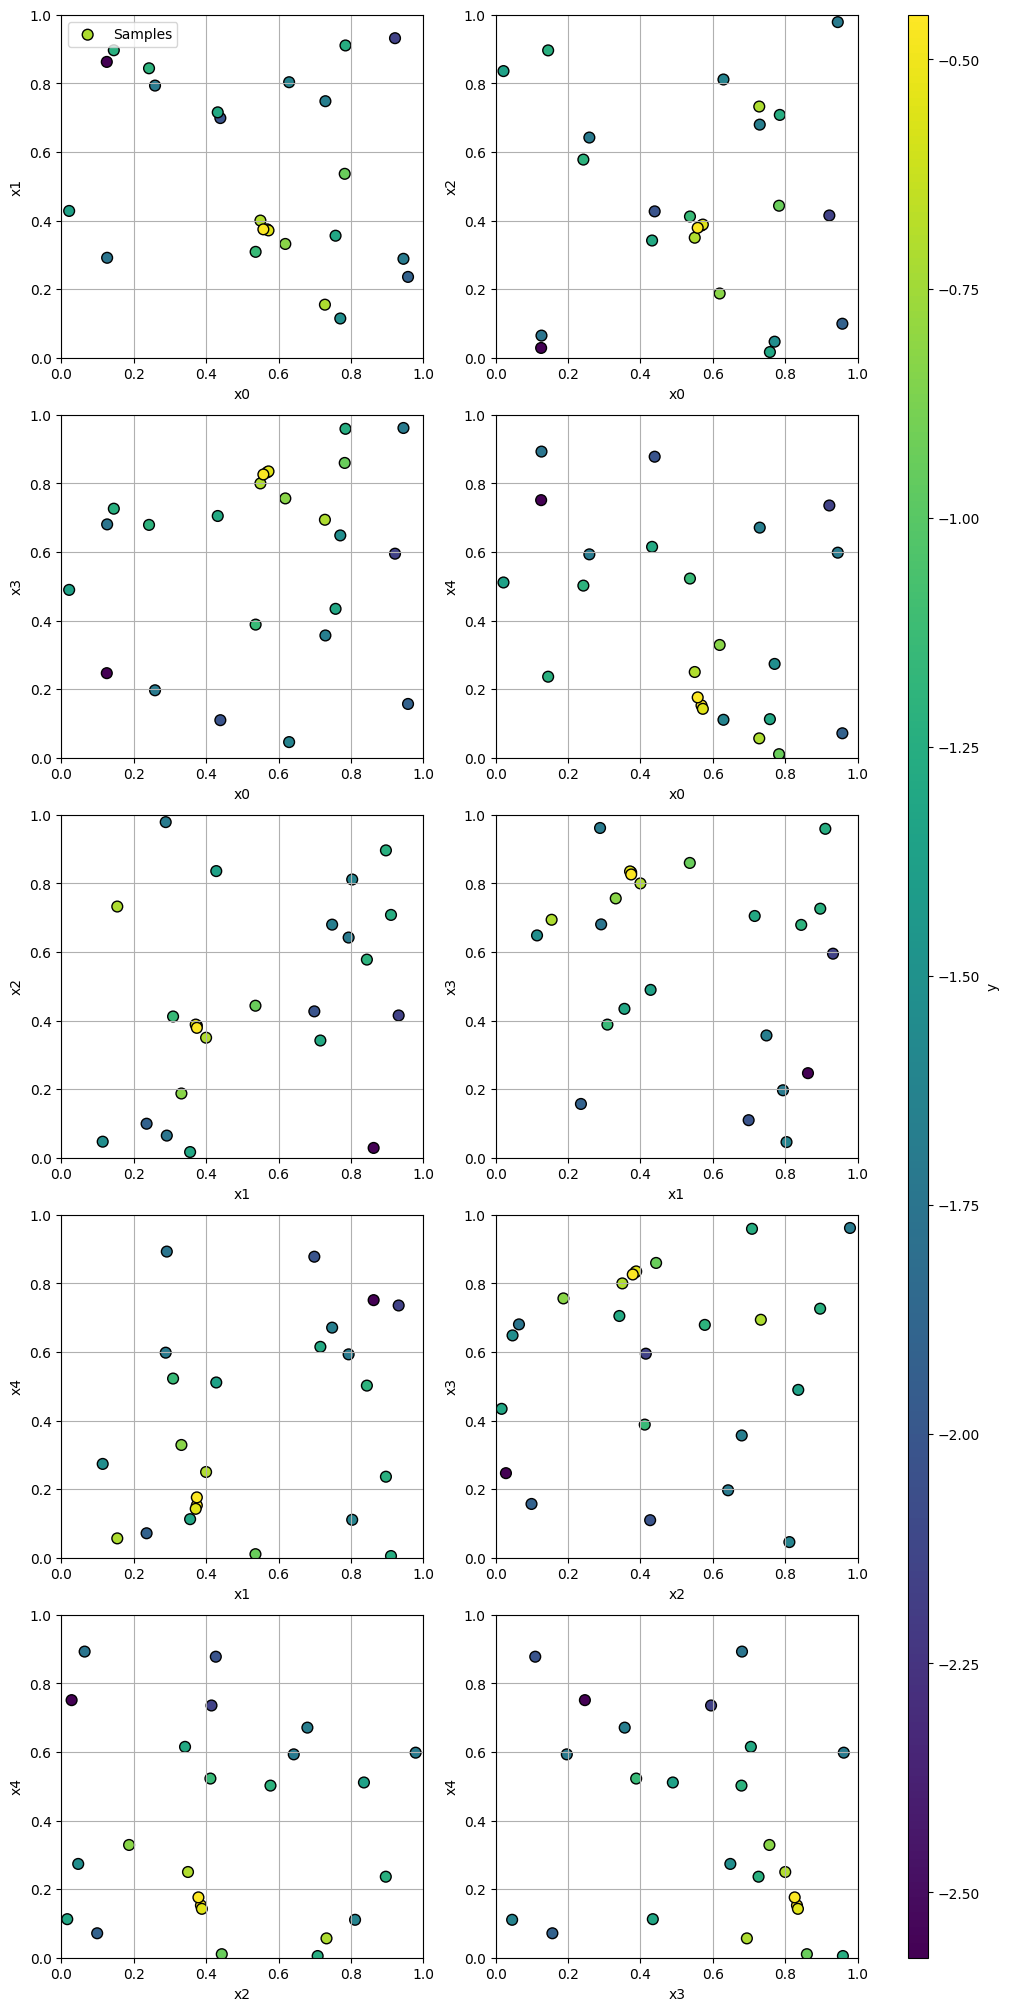

In [19]:
fig, axs = plot_2d_array(X, y)

As the distance between the proposed and best points has been gradually decreasing, we may have reached the point of diminishing returns when exploiting this region. We can return to this region later for further exploitation but adopting a policy of exploration would allow us to test our assumption that there is only one maximum. Therefore, as before we can train a Gaussian Process surrogate model with a recursive grid search to find candidate points. However, we can assess the candidate points with a more exploratory Upper Confidence Bound (UCB) acquisition function with exploration parameter `k` = 1.96:

In [20]:
# Fit Gaussian Process surrogate model on known data
model = get_reg_model(
    n_dimensions=n_dimensions,
    seed_input=seed_input,
    initial_length_scale=0.1,
    length_scale_bounds=(1e-2, 100),
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: {length_scales}")

# Perform grid search with Upper Confidence Bound (UCB) acquisition function with k = 1.96
x_next = grid_search(model, acq_func=acquisition.ucb, k=1.96, n_dimensions=n_dimensions, grd_res=grd_res)
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")
print(f"Distance between proposed point and best point = {np.linalg.norm(x_next - x_best)}")
print(f"Distance between proposed point and nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}")

/home/chagani/projects/github/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chagani/projects/github/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Length scales: [1.00000000e+02 1.76832187e-02 1.00000000e+02 5.03722771e-01
 1.59362137e+00]
Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.61127411 0.16127411 0.99999911 0.11127411 0.01127411]
Distance between proposed point and best point = 0.982083265832748
Distance between proposed point and nearest neighbour = 0.653331251530317


The length scales for features `x0` and `x2` hit the upper boundary, suggesting that the model believes the output to be less sensitive to changes in these dimensions. It is now feature `x1` which has a length scale that is approximately an order of magnitude smaller than the next largest length scale. The changes that have been witnessed in the length scales as a result of the last few queries is an indication of the instability of the model. This is not too surprising given the relatively small number of data points across the 5-dimensional domain. Additionally, we have been exploring a relatively small region of the domain, and the length scales attempt to map this globally. Therefore, they cannot be fully relied upon.

We obtain a proposed point that is significantly far from both the best observed point and its nearest neighbour. This is not too surprising given that there are few data points in this region, and therefore it is likely that the model's uncertainty is higher here.

As noted before, an unknown random seed was used to intialise the Gaussian Process surrogate model in the original analysis. According to this model, the UCB acquisition function was maximised at the point (0.5687, 0.163645, 0.38575, 0.155556, 0.034445). This is a considerable distance from the proposed point above. Taking a closer look at this point, we can determine how far it lies from its nearest neighbour, which will give an indication of its isolation:

In [21]:
submitted_point = np.array([0.5687, 0.163645, 0.38575, 0.155556, 0.034445])
print(f"Distance between submitted point and best point = {np.linalg.norm(x_best - submitted_point)}")
print(f"Distance between submitted point and proposed point = {np.linalg.norm(x_next - submitted_point)}")
print(f"Distance between submitted point and nearest neighbour = {np.min(np.linalg.norm(X - submitted_point, axis=1))}")

Distance between submitted point and best point = 0.7186460361332274
Distance between submitted point and proposed point = 0.6177523130584709
Distance between submitted point and nearest neighbour = 0.489941151792175


The submitted point lies significantly far from its nearest neighbour, indicating that it also lies in a region of high uncertainty arising from a lack of data. Therefore, the justification for selecting the submitted point is consistent with that for the proposed point above.

## Week 6 - Looking for other promising regions

In [22]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

from bbo import acquisition
from bbo.bayesian_optimisation import get_reg_model
from bbo.clustering import get_dbscan_labels
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array, plot_nearest_neighbour_distance
from bbo.random import get_candidates_uniform

seed_input = "function 6"  # input string to create random seed
n_dimensions = 5  # number of features
grd_res = 21  # axis resolution

In [23]:
X, y = get_current_weeks_points(function_id=6, week=6)

print(f"Last week's query {X[-1]} yields {y[-1]}")
print(f"Mean output = {y.mean()}")

Last week's query [0.5687   0.163645 0.38575  0.155556 0.034445] yields -1.315925330019023
Mean output = -1.3358829654427584


Last week's query yields an output that lies close to the mean. Given that we have adopted a policy of exploration over exploitation for the time being, it is not surprising that the output from last week's query is significantly lower than the maximum. This result provides us with more information about the underlying function and suggests that this region is not a promising one to explore further.

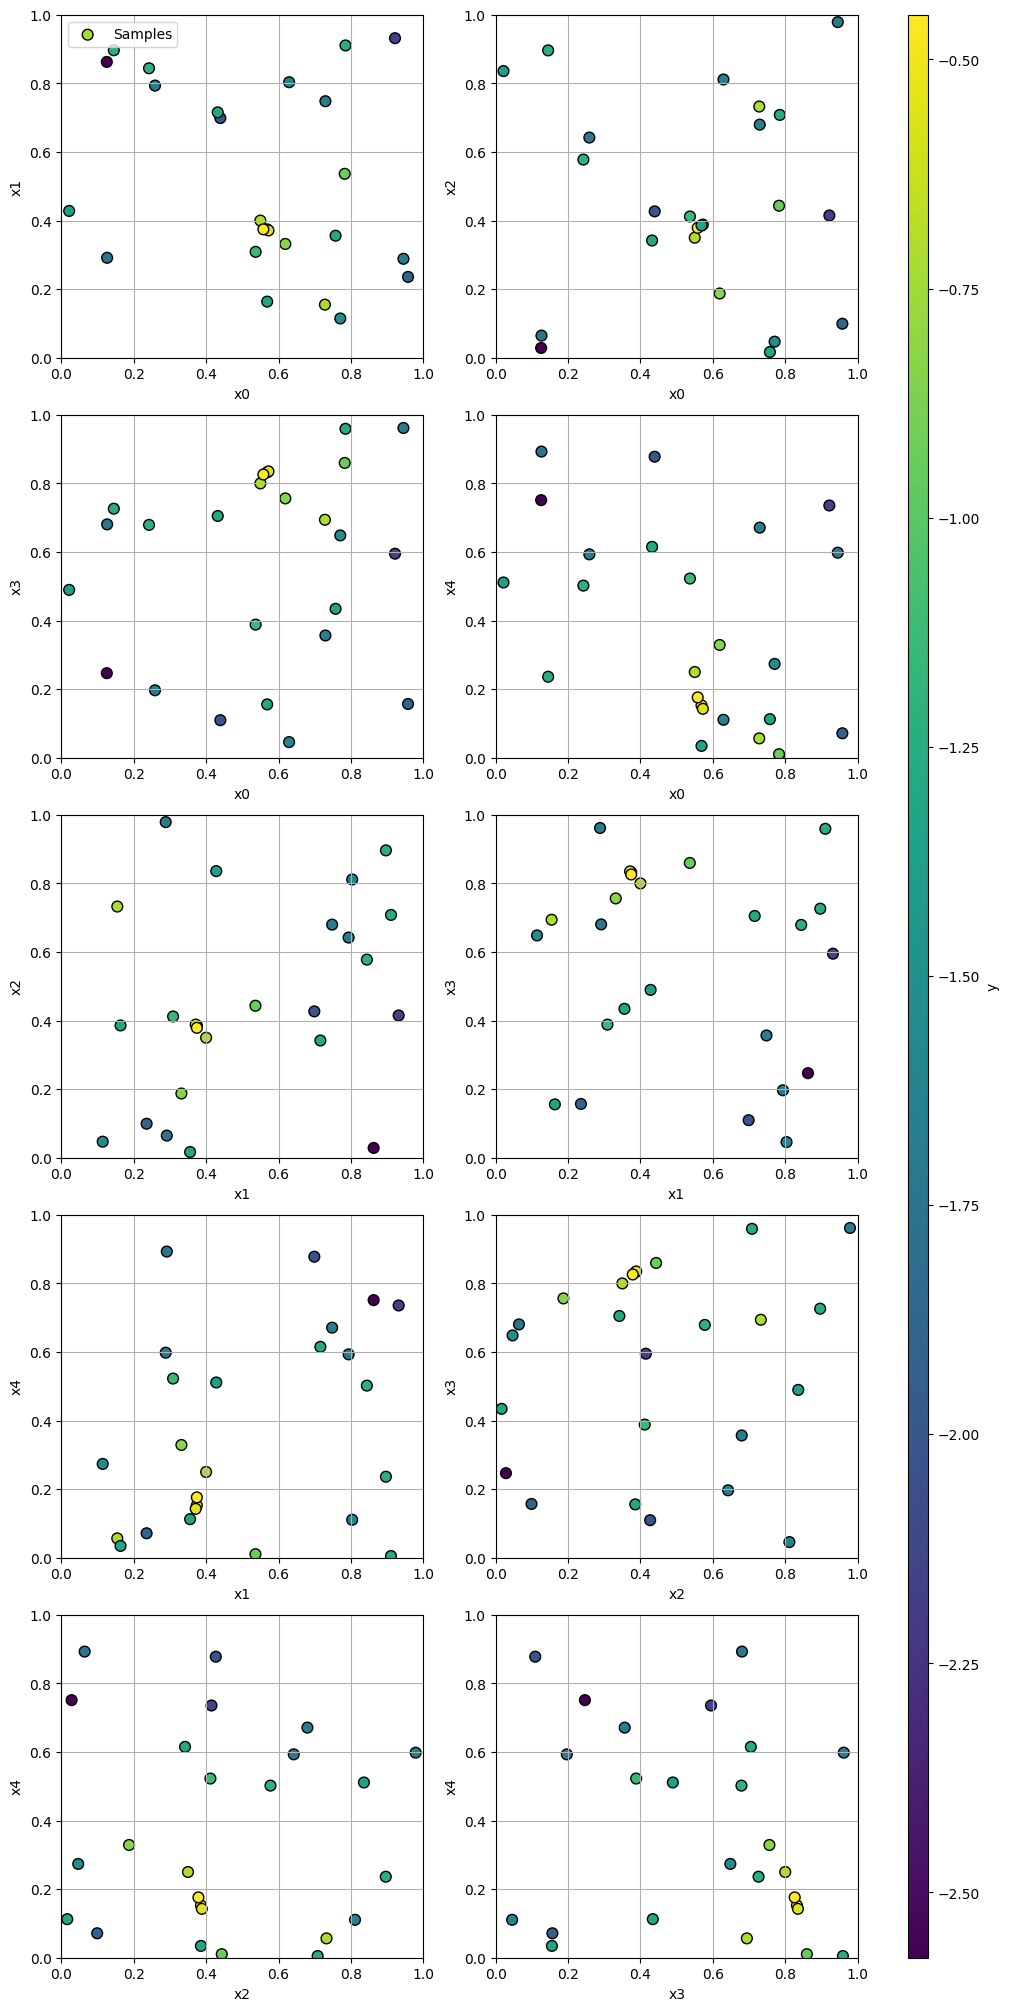

In [24]:
fig, axs = plot_2d_array(X, y)

While we can continue to use an Upper Confidence Bound (UCB) function to assess candidate points in a grid search, the relatively poor grid resolution means that certain regions may get overlooked. A more fruitful method may be to employ a random search, where we generate candidate points at random and assess them with the UCB acquisition function. To encourage exploration, a distance-dependent penalty was introduced to discourage repeated sampling close to the best point.

We can generate sets of these candidate points, and for each iteration keep the 5 with highest output. Then, using a Density Based Spatial Clustering of Applications with Noise (DBSCAN) algorithm, we can divide these candidates into clusters. To find a suitable value for the maximum distance between two samples in the same neighbourhood, we can plot the distances of each point to its 5th nearest neighbour and estimate the position where there is significant change in this distance. We can define a dense region as one where a point has 5 neighbours:

/home/chagani/projects/github/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chagani/projects/github/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Length scales: [1.00000000e+02 1.78089977e-02 1.00000000e+02 4.24954228e-01
 1.71730088e+00]


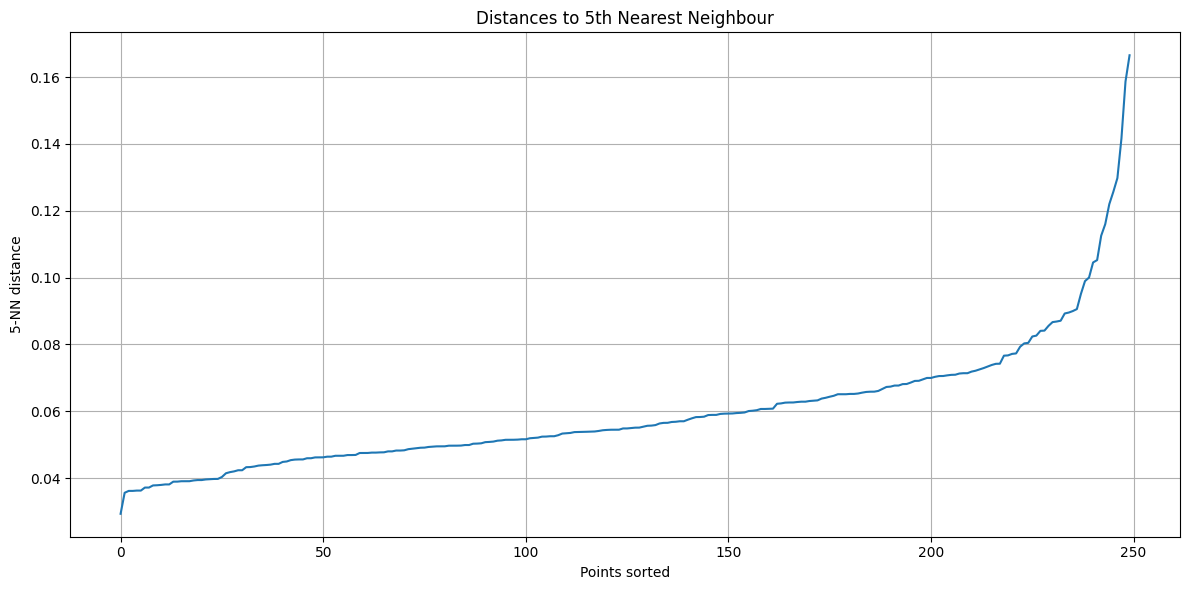

In [25]:
# Fit Gaussian Process surrogate model with RBF kernel on known data
model = get_reg_model(
    n_dimensions=n_dimensions, seed_input=seed_input, length_scale_bounds=(1e-3, 100)
)
model.fit(X, y)

length_scales = model.kernel_.length_scale
print(f"Length scales: {length_scales}")

# Find best point and predicted value there
max_idx = np.argmax(y)
x_best = X[max_idx]
pred_x_best = model.predict(x_best.reshape(1, -1))

n_trials = 50  # number of iterations
n_random = 10_000  # number of candidate points to generate per iteration
n_top_candidates = 5  # number of top candidate points to keep after every iteration
candidates = []
for X_rand in get_candidates_uniform(
    n_trials=n_trials,
    n_random=n_random,
    n_dimensions=n_dimensions,
    seed_input=seed_input,
    bounds=(0.05, 0.95)
):
    y_mean, y_std = model.predict(X_rand, return_std=True)

    # Use Upper Confidence Bound (UCB) as metric
    acq = acquisition.ucb(y_mean, y_std, k=1.96)

    # Penalise acquisition around best point
    square_radius = np.sum(((X_rand - x_best) / length_scales) ** 2, axis=1)
    penalty = pred_x_best * np.exp(-0.5 * square_radius)  # penalty decays with distance from best point
    acq -= penalty

    # Keep top candidates
    top_idx = np.argsort(acq)[-n_top_candidates:]
    candidates.append(X_rand[top_idx])

candidates = np.vstack(candidates)
# Scale candidates relative to best point and length scales
X_scaled = (candidates - x_best) / length_scales

k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = distances[:, -1]  # get distances to kth nearest neighbours
fig, ax = plot_nearest_neighbour_distance(distances=k_distances, k=5)

The length scales indicate that the model believes the output is relatively insensitive to changes in the `x0` and `x2` dimensions.

From the plot above, we see a significant change at the position of the elbow, where the distance between a point and its 5th nearest neighbour lies between 0.07 and 0.08. We can be aggressive and define the maximum distance between two points for them to be considered to be in the same neighbourhood for the DBSCAN algorithm as the lower value of 0.07. We then define the centre of each cluster to be the median position:

In [26]:
max_distance = 0.07
cluster_labels = get_dbscan_labels(points=X_scaled, max_distance=max_distance, min_samples=k)

labels, counts = np.unique(cluster_labels, return_counts=True)

for lbl, count in zip(labels, counts):
    if lbl == -1:  # noise
        continue

    clusterer_points = candidates[cluster_labels == lbl]
    x_median = np.median(clusterer_points, axis=0)  # median of cluster
    mean, std = model.predict(x_median.reshape(1, -1), return_std=True)

    print(f"Cluster {lbl}, number of points = {count}")
    print(f"Proposed point as the median of the cluster = {x_median}")
    print(f"Predicted value = {mean[0]}, standard deviation = {std[0]}")
    print(f"Distance between proposed point and best point = {np.linalg.norm(x_median - x_best)}")
    print(f"Distance between proposed point and nearest neighbour = {np.min(np.linalg.norm(X - x_median, axis=1))}\n")

Cluster 0, number of points = 233
Proposed point as the median of the cluster = [0.55280031 0.38283187 0.46563691 0.93070611 0.48976646]
Predicted value = -0.31256122233005335, standard deviation = 0.16766118164701277
Distance between proposed point and best point = 0.3606103526434824
Distance between proposed point and nearest neighbour = 0.2970631615844939



The candidate points form a single cluster. The positional median provides a good representation of each cluster but does not take the acquisition function into account. It simply provides a promising point to query in that cluster. The predicted output of the positional median has a relatively high error, likely a result of the poor coverage in the region surrounding this point. The distance between the median point and its nearest neighbour is large enough to suggest that it lies within a new, unexplored region.

However, the median point may not be the best candidate to query. We can use a purely exploratory acquisition function by finding the candidate with the largest uncertainty in the cluster:

In [27]:
for lbl, count in zip(labels, counts):
    if lbl == -1:  # noise
        continue

    clusterer_points = candidates[cluster_labels == lbl]
    mean, std = model.predict(clusterer_points, return_std=True)
    max_idx = np.argmax(std)
    x_max_std = clusterer_points[max_idx]  # most uncertain point

    print(f"Cluster {lbl}, number of points = {count}")
    print(f"Proposed point as the candidate with the greatest uncertainty = {x_max_std}")
    print(f"Predicted value = {mean[max_idx]}, standard deviation = {std[max_idx]}")
    print(f"Distance between proposed point and best point = {np.linalg.norm(x_max_std - x_best)}")
    print(f"Distance between proposed point and nearest neighbour = {np.min(np.linalg.norm(X - x_max_std, axis=1))}\n")

Cluster 0, number of points = 233
Proposed point as the candidate with the greatest uncertainty = [0.64811942 0.38626091 0.72543671 0.93778262 0.94861735]
Predicted value = -0.48823807044354794, standard deviation = 0.2662264712434409
Distance between proposed point and best point = 0.8755287928988079
Distance between proposed point and nearest neighbour = 0.5342578462180745



Arguably this point provides more information on the structure of the underlying function as we are querying the point at which the model is least certain. This point is also farther its nearest neighbour, and therefore will be probing a previously unexplored region. For these reasons, the candidate with the largest standard deviation was selected as this week's query.

A different random seed was used to generate the candidate points in the original analysis, resulting in a different candidate that had the greatest uncertainty. The point (0.446886, 0.384235, 0.617341, 0.95, 0.95) was submitted for this week's query. The values for features `x1`, `x3` and `x4` are very similar to the proposed point above. However, the values for `x0` and `x2` are considerably different. As the length scales in both of these dimensions reached the upper boundary, the model believes that the slope is fairly flat in these dimensions. Therefore, according to the model the values of these features should have little effect on the output.

## Week 7 - Exploring the most promising region

In [28]:
import numpy as np

from bbo import acquisition, decision_trees
from bbo.bayesian_optimisation import get_reg_model
from bbo.clustering import get_agglomerative_clusterer
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array, plot_decision_tree
from bbo.utils import construct_meshgrid, grid_search_mean

seed_input = "function 6"  # input string to create random seed
n_dimensions = 5  # number of features
grd_res = 21  # axis resolution

In [29]:
X, y = get_current_weeks_points(function_id=6, week=7)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.446886 0.384235 0.617341 0.95     0.95    ] yields -1.1662139935152562


Last week's query yields a relatively small output, in line with previous exploratory queries, and indicates that this may not be a promising region to explore.

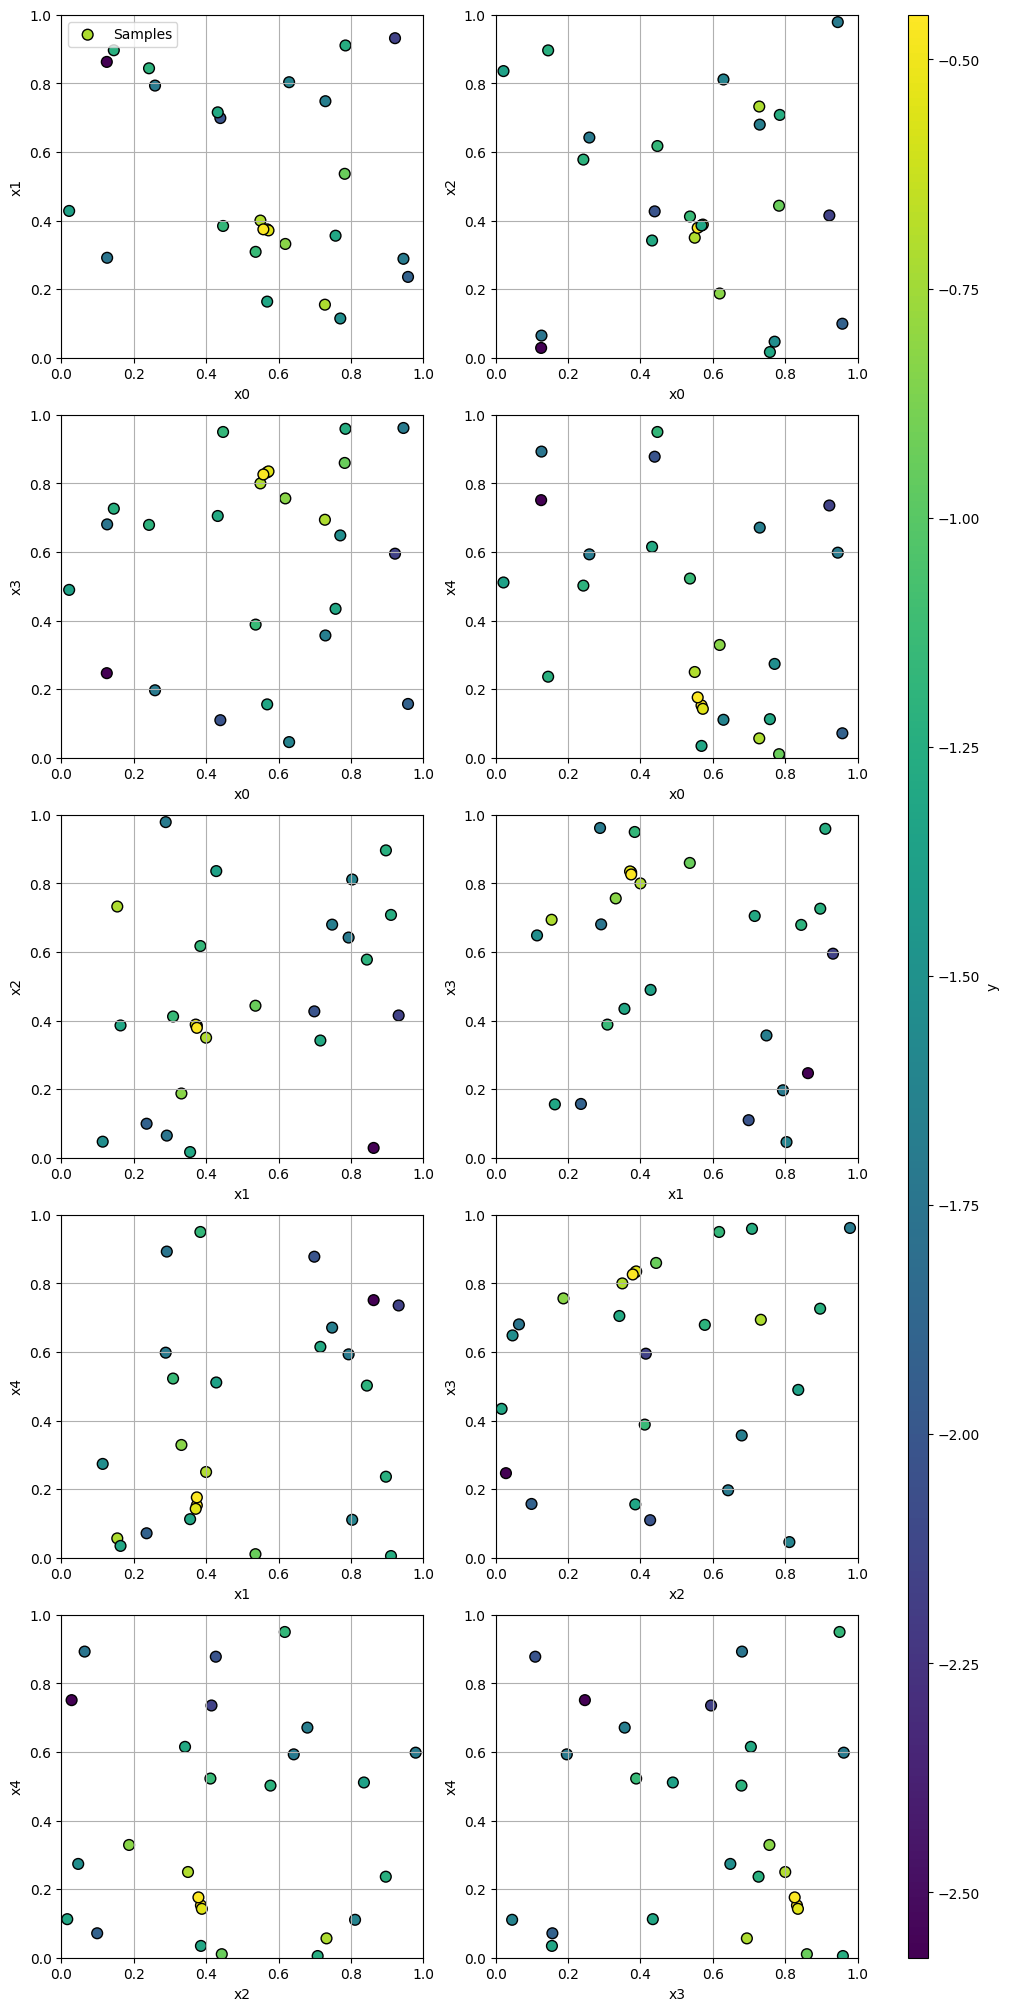

In [30]:
fig, axs = plot_2d_array(X, y)

From the above plots, the promising region we identified earlier lies around the coordinates (0.55, 0.4, 0.4, 0.85, 0.15). However, as we identified earlier, not all features contribute equally to the output. While we do not have enough data points to determine with any certainty which features have a greater effect on the output in the promising region, we can attempt to do this with a global model. As we have done in past weeks, using a global Gaussian Process surrogate model trained on the entire, we can estimate the sensitivity of the output to changes in each feature:

In [31]:
# Fit Gaussian Process surrogate model with RBF kernel and initial length
# scales of 0.1 in each dimension
gp_model = get_reg_model(
    n_dimensions=n_dimensions,
    seed_input=seed_input,
    length_scale_bounds=(1e-2, 100),
)
gp_model.fit(X, y)

length_scales = gp_model.kernel_.length_scale
print(f"Length scales: {length_scales}")

Length scales: [1.00000000e+02 1.71778177e-02 1.00000000e+02 4.70346386e-01
 7.67329167e-01]


/home/chagani/projects/github/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/chagani/projects/github/AICapstoneProject_IC/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


According to the length scales, the Gaussian Process model believes that `x0` and `x2` are fairly flat across the domain.

While we can continue with Bayesian Optimisation, it is sensitive to our choice of kernel. Alternatively, we can use a decision tree ensemble model such as random forests or extra trees (extremely randomised trees). As these ensembles consist to many trees, the mean output and standard deviation can be used as a measure of model uncertainty.

In the decision tree below, splits primarily occur on the `x1`, `x3` and `x4` features. This suggests that these features are influential given our current knowledge of the domain, which is in line with the Gaussian Process surrogate model's length scales:

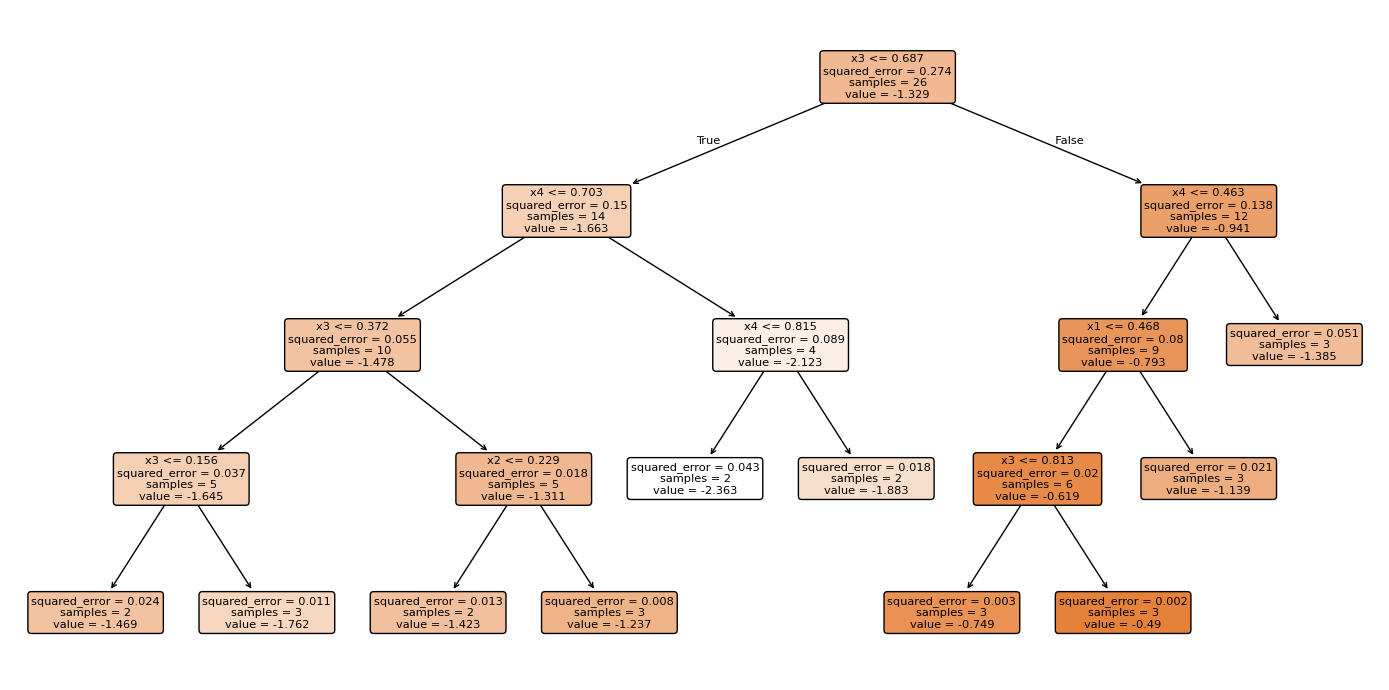

In [32]:
tree = decision_trees.get_decision_tree(
    max_depth=5, min_samples_leaf=2, seed_input=seed_input
)
tree.fit(X, y)

fig, ax = plot_decision_tree(tree=tree, n_dimensions=n_dimensions)

The exact configuration of the decision tree is sensitive to the random seed, and it is possible that a different conclusion to the above could be reached if another seed was used. We can mitigate this by using an ensemble of models and taking the mean, as differences between the models should be averaged out.

We compare two ensembling techniques here: random forests, where the best splits are found for each feature according to a metric and the data points are sampled with replacement (i.e. bootstrapping); and extra trees, where the split thresholds are chosen at random but the entire data set is used to build each tree (i.e. no bootstrapping). We can build a grid and evaluate the model's output with an Upper Confidence Bound (UCB) acquisition function, with exploration parameter `k` = 1.96. As mentioned in week 5, the UCB acquisition function is more exploratory than the Probability of Improvement (PI) acquisition function:

In [33]:
tree_model_params = {
    "n_estimators": 500,
    "max_depth": 5,
    "min_samples_leaf": 2,
    "seed_input": seed_input,
}

# Fit random trees ensemble model
rf = decision_trees.get_random_forests_model(**tree_model_params)
rf.fit(X, y)

# Perform grid search to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X_.ravel() for X_ in X_grid])
rf_mean, rf_std = decision_trees.get_ensemble_stats(rf, X_pred)

# Extract best candidates from grid as those where Upper Confidence Bound (UCB)
# function is at maximum value and calculate centroid to find proposed point.
acq_func = acquisition.ucb(rf_mean, rf_std, k=1.96)
mask = np.isclose(acq_func, acq_func.max(), rtol=1e-6, atol=1e-9)
best_candidates = X_pred[mask]
x_next = best_candidates.mean(axis=0)
print(f"Proposed point from random forest ensemble model = {x_next}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}")

# Use agglomerative clusterer to indicate whether best candidates are
# concentrated in a region or far apart
clusterer = get_agglomerative_clusterer(n_dimensions=n_dimensions)
labels = clusterer.fit_predict(best_candidates)
clusters, counts = np.unique(labels, return_counts=True)
for cluster, count in zip(clusters, counts):
    print(f"Cluster {cluster}, counts = {count}")
print("")

# Fit extremely randomised trees ensemble model
et = decision_trees.get_extra_trees_model(**tree_model_params)
et.fit(X, y)

# Perform grid search to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X_.ravel() for X_ in X_grid])
et_mean, et_std = decision_trees.get_ensemble_stats(et, X_pred)

# Extract best candidates from grid as those where Upper Confidence Bound (UCB)
# function is at maximum value and calculate centroid to find proposed point.
acq_func = acquisition.ucb(et_mean, et_std, k=1.96)
mask = np.isclose(acq_func, acq_func.max(), rtol=1e-6, atol=1e-9)
best_candidates = X_pred[mask]
x_next = best_candidates.mean(axis=0)
print(f"Proposed point from extra trees ensemble model = {x_next}")
print(f"Distance of proposed point from nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}")

# Use agglomerative clusterer to indicate whether best candidates are
# concentrated in a region or far apart
clusterer = get_agglomerative_clusterer(n_dimensions=n_dimensions)
labels = clusterer.fit_predict(best_candidates)
clusters, counts = np.unique(labels, return_counts=True)
for cluster, count in zip(clusters, counts):
    print(f"Cluster {cluster}, counts = {count}")

Proposed point from random forest ensemble model = [0.55  0.35  0.05  0.85  0.775]
Distance of proposed point from nearest neighbour = 0.47480964936362957
Cluster 0, counts = 6

Proposed point from extra trees ensemble model = [0.1   0.35  0.075 0.85  0.15 ]
Distance of proposed point from nearest neighbour = 0.541410195692693
Cluster 0, counts = 10


The relatively poor grid resolution across a 5-dimensional domain as a result of computational limits may explain why both proposed points have the same `x1` and `x3` values. These line up well with the coordinates of the promising region we estimated from the plots above, where `x1` = 0.4 and `x3` = 0.85. This is not unexpected as both models have been trained on the same sparse dataset and are strongly influenced by this promising region we identified earlier. Both the Gaussian Process surrogate and decision tree models suggest that the output is less sensitive to changes in `x0` and `x2`, although this could be a product of sparse sampling and may not be true. We are left with the `x4` feature. Our previous estimate of the location of the promising region at `x4` = 0.15 lines up well with the proposed point from the extra trees ensemble model. Therefore, we should investigate the region around this point.

Unlike the smooth outputs from Gaussian Process models, those from decision tree ensemble models are more discrete. Therefore, many candidate points may maximise the acquisition function, and hence the mean position of these candidates is calculated to find a single representative point. Due to the relatively poor grid resolution, performing a recursive grid search around the proposed point can help to refine it:

In [34]:
x_next = grid_search_mean(
    model=et,
    acq_func=acquisition.ucb,
    k=1.96,
    n_dimensions=n_dimensions,
    grd_res=grd_res,
)
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function on extra trees ensemble model = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function on extra trees ensemble model = [0.12375 0.37375 0.09875 0.87375 0.17375]


As a different random seed was used in the original analysis, the point submitted as this week's query was (0.07, 0.23, 0.064182, 0.836, 0.276). With reference to the decision tree model above, both the proposed point and submitted point lie in the region with the highest mean output (i.e. `value` in the decision tree plot). As the Gaussian Process surrogate and decision tree models suggest that the output may be less sensitive to changes in `x0` and `x2`, the submitted and proposed points can be considered to lie in the same region.

## Week 8 - Investigating the importance of `x0`

In [35]:
import numpy as np

from bbo import acquisition, decision_trees
from bbo.clustering import get_agglomerative_clusterer
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array, plot_decision_tree
from bbo.utils import construct_meshgrid, grid_search_mean

seed_input = "function 6"  # input string to create random seed
n_dimensions = 5  # number of features
grd_res = 21  # axis resolution

In [36]:
X, y = get_current_weeks_points(function_id=6, week=8)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.07     0.23     0.064182 0.836    0.276   ] yields -1.4084589867999573


Last week's output yields a low output, which may be an indcation that the output may be more sensitive to changes in the `x0` and `x2` features than previously thought.

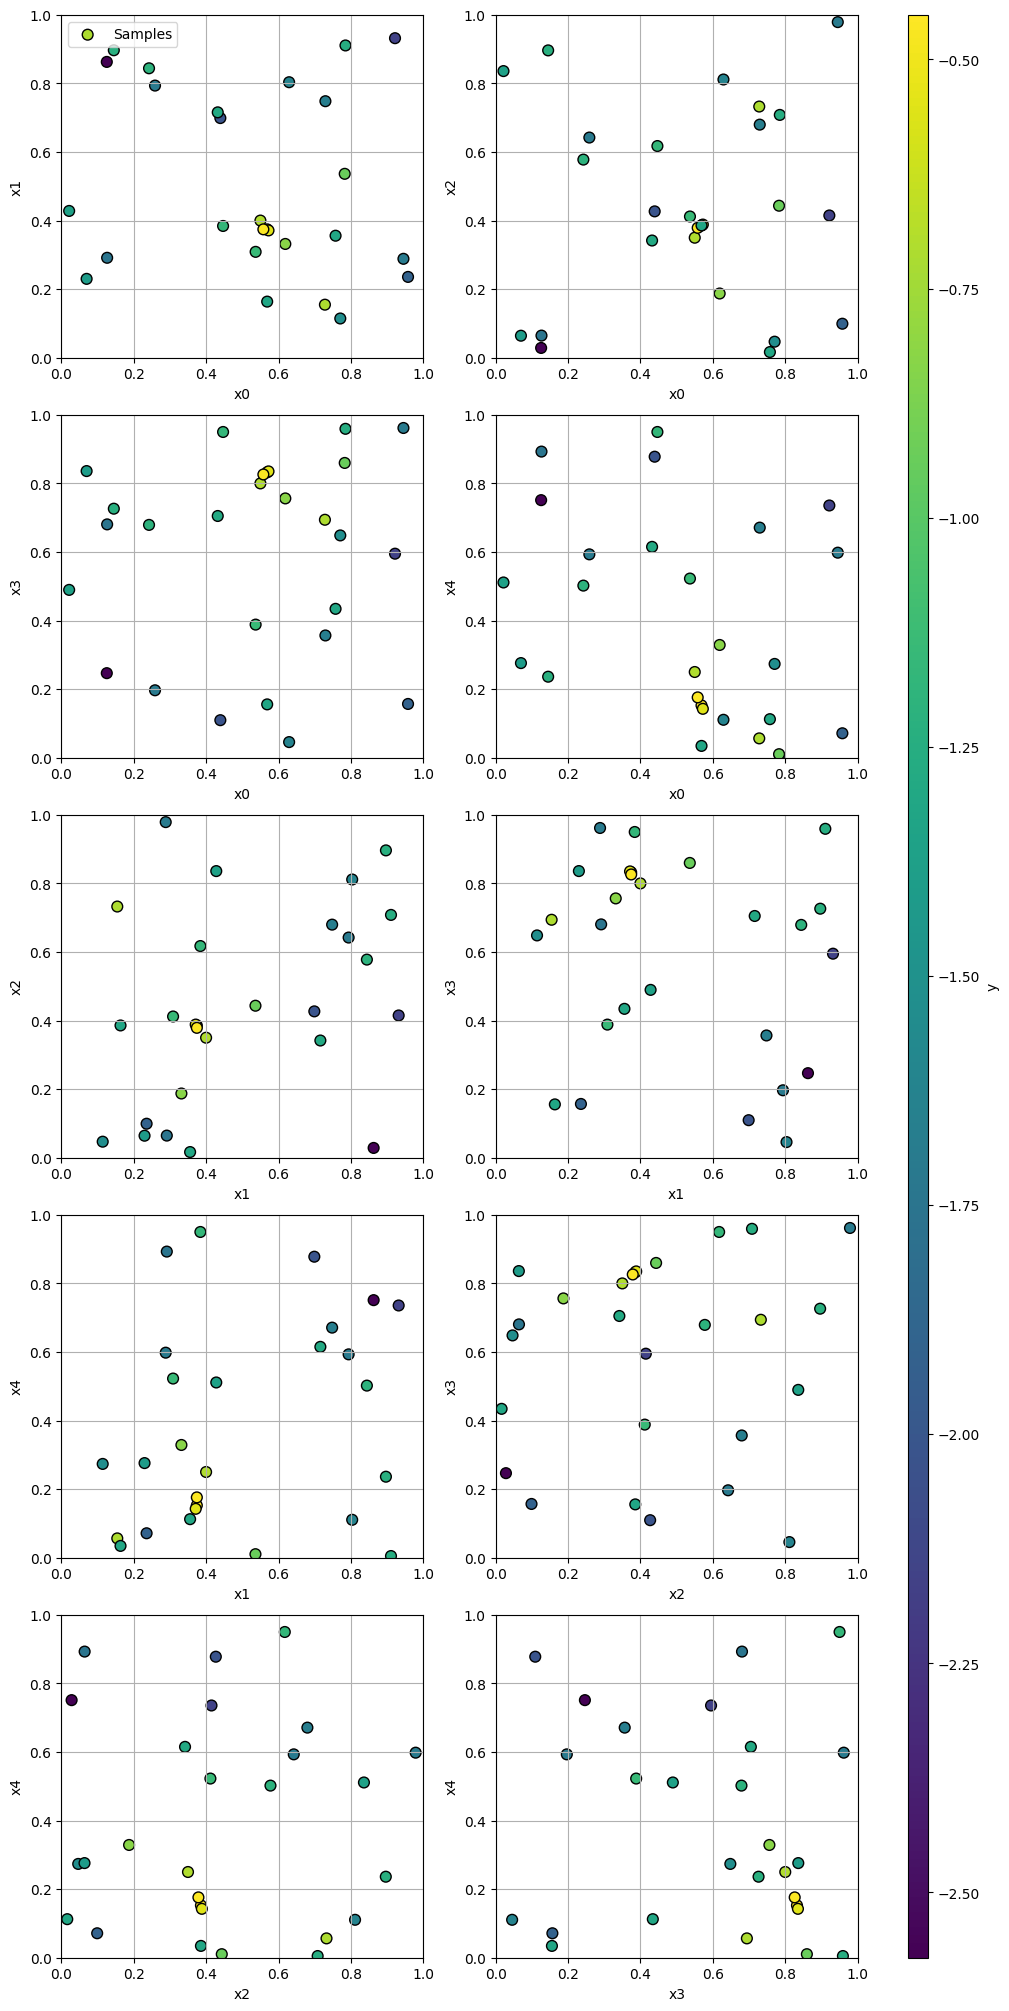

In [37]:
fig, axs = plot_2d_array(X, y)

We can get an idea of any changes by training a new decision tree model:

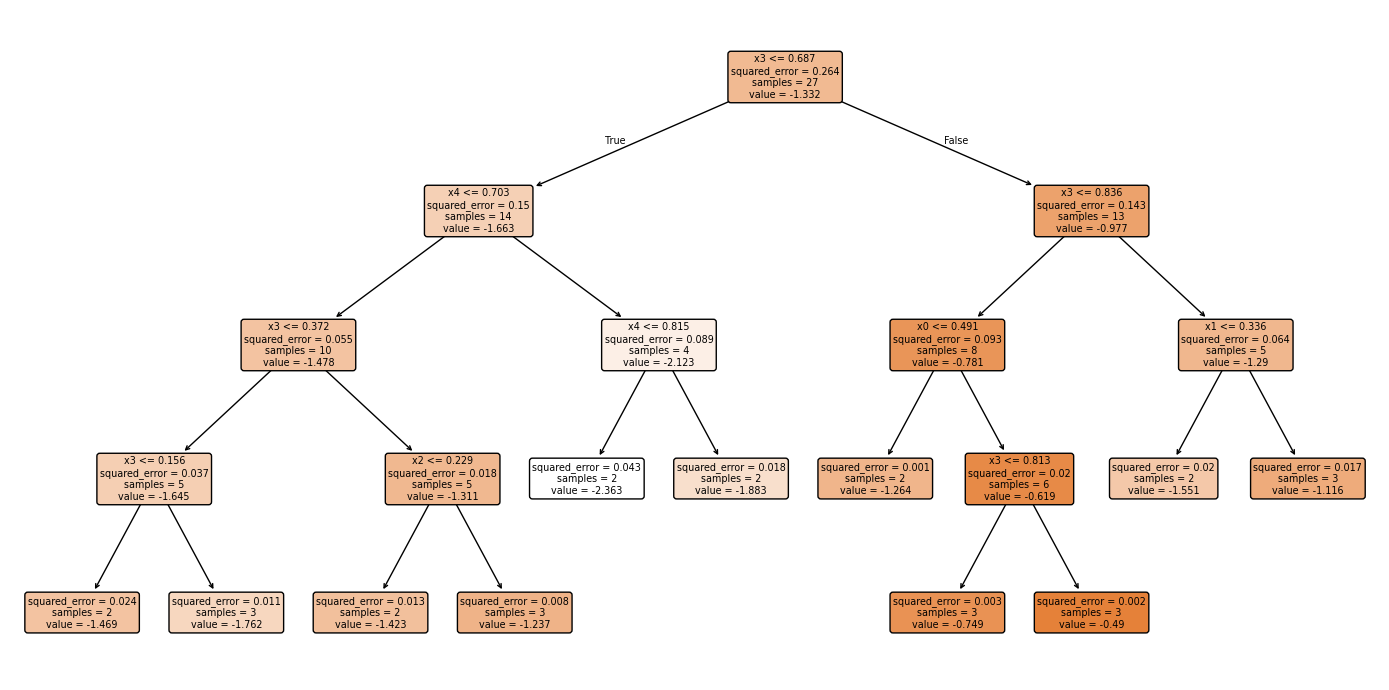

In [38]:
tree = decision_trees.get_decision_tree(
    max_depth=5, min_samples_leaf=2, seed_input=seed_input
)
tree.fit(X, y)

fig, ax = plot_decision_tree(tree=tree, n_dimensions=n_dimensions)

From the plot above, the leaf with the highest value (i.e. mean output) is found by splitting on features `x0` and `x3`. However, this is a single decision tree model, and another decision tree initialised with a different random seed could reach a different conclusion. As discussed before, this can be mitigated by training multiple decision trees in ensemble models and extracting the mean of candidate points and their standard deviations as measures of uncertainty. As last week, we adopt an extra trees (extremely randomised trees) ensemble model and perform a recursive grid search around the mean of the candidates that maximise the Upper Confidence Bound (UCB) acquisition function:

In [39]:
tree_model_params = {
    "n_estimators": 500,
    "max_depth": 5,
    "min_samples_leaf": 2,
    "seed_input": seed_input,
}

# Fit extremely randomised trees ensemble model
et = decision_trees.get_extra_trees_model(**tree_model_params)
et.fit(X, y)

# Perform grid search to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X_.ravel() for X_ in X_grid])
et_mean, et_std = decision_trees.get_ensemble_stats(et, X_pred)

# Extract best candidates from grid as those where Upper Confidence Bound (UCB)
# function is at maximum value and calculate centroid to find proposed point.
acq_func = acquisition.ucb(et_mean, et_std, k=1.96)
mask = np.isclose(acq_func, acq_func.max(), rtol=1e-6, atol=1e-9)
best_candidates = X_pred[mask]
x_next = best_candidates.mean(axis=0)
print(f"Proposed point from extra trees ensemble model = {x_next}")

# Use agglomerative clusterer to indicate whether best candidates are
# concentrated in a region or far apart
if len(best_candidates) < 2:
    labels = np.array([0])  # single cluster
else:
    clusterer = get_agglomerative_clusterer(n_dimensions=n_dimensions)
    labels = clusterer.fit_predict(best_candidates)
clusters, counts = np.unique(labels, return_counts=True)
res = 1.0 / grd_res
for cluster, count in zip(clusters, counts):
    print(f"Cluster {cluster}, counts = {count}")

    # Perform grid search for each cluster
    mask = labels == cluster
    cluster_candidates = best_candidates[mask]
    x_centre = cluster_candidates.mean(axis=0)
    bounds = [(max(0.0, x_ - res), min(1.0, x_ + res)) for x_ in x_centre]
    x_next = grid_search_mean(
        model=et,
        acq_func=acquisition.ucb,
        k=1.96,
        n_dimensions=n_dimensions,
        grd_res=grd_res,
        bounds=bounds,
    )
    print(f"Proposed point from cluster {cluster} = {x_next}")

Proposed point from extra trees ensemble model = [0.6  0.85 0.35 0.8  0.15]
Cluster 0, counts = 1
Proposed point from cluster 0 = [0.57547619 0.84928571 0.36833333 0.81357143 0.14928571]


Only one candidate point maximises the UCB function. The proposed point lies in the high-value region identified by the decision tree model above.

As mentioned previously, given the relatively few data points there are likely to be variations between ensemble models that have been initialiised with different random seeds. As a different random seed was used during the original analysis, the point (0.5668, 0.23, 0.392, 0.8324, 0.276) was submitted this week. Although the submitted point differs from the proposed point, their similarity in the `x0` and `x3` dimensions means the submitted point still probes the same high-value region identified by the decision tree model above.

## Week 9 - Exploring sensitivity to changes in `x1` and `x4`

In [40]:
import numpy as np

from bbo import acquisition, decision_trees
from bbo.clustering import get_agglomerative_clusterer
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array, plot_decision_tree
from bbo.utils import construct_meshgrid, grid_search_mean

seed_input = "function 6"  # input string to create random seed
n_dimensions = 5  # number of features
grd_res = 21  # axis resolution

In [41]:
X, y = get_current_weeks_points(function_id=6, week=9)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.5668 0.23   0.392  0.8324 0.276 ] yields -0.7535815596107908


The output from last week's query is an improvement from our previous query. Although not as high as the current best observed point, it is of relatively high value.

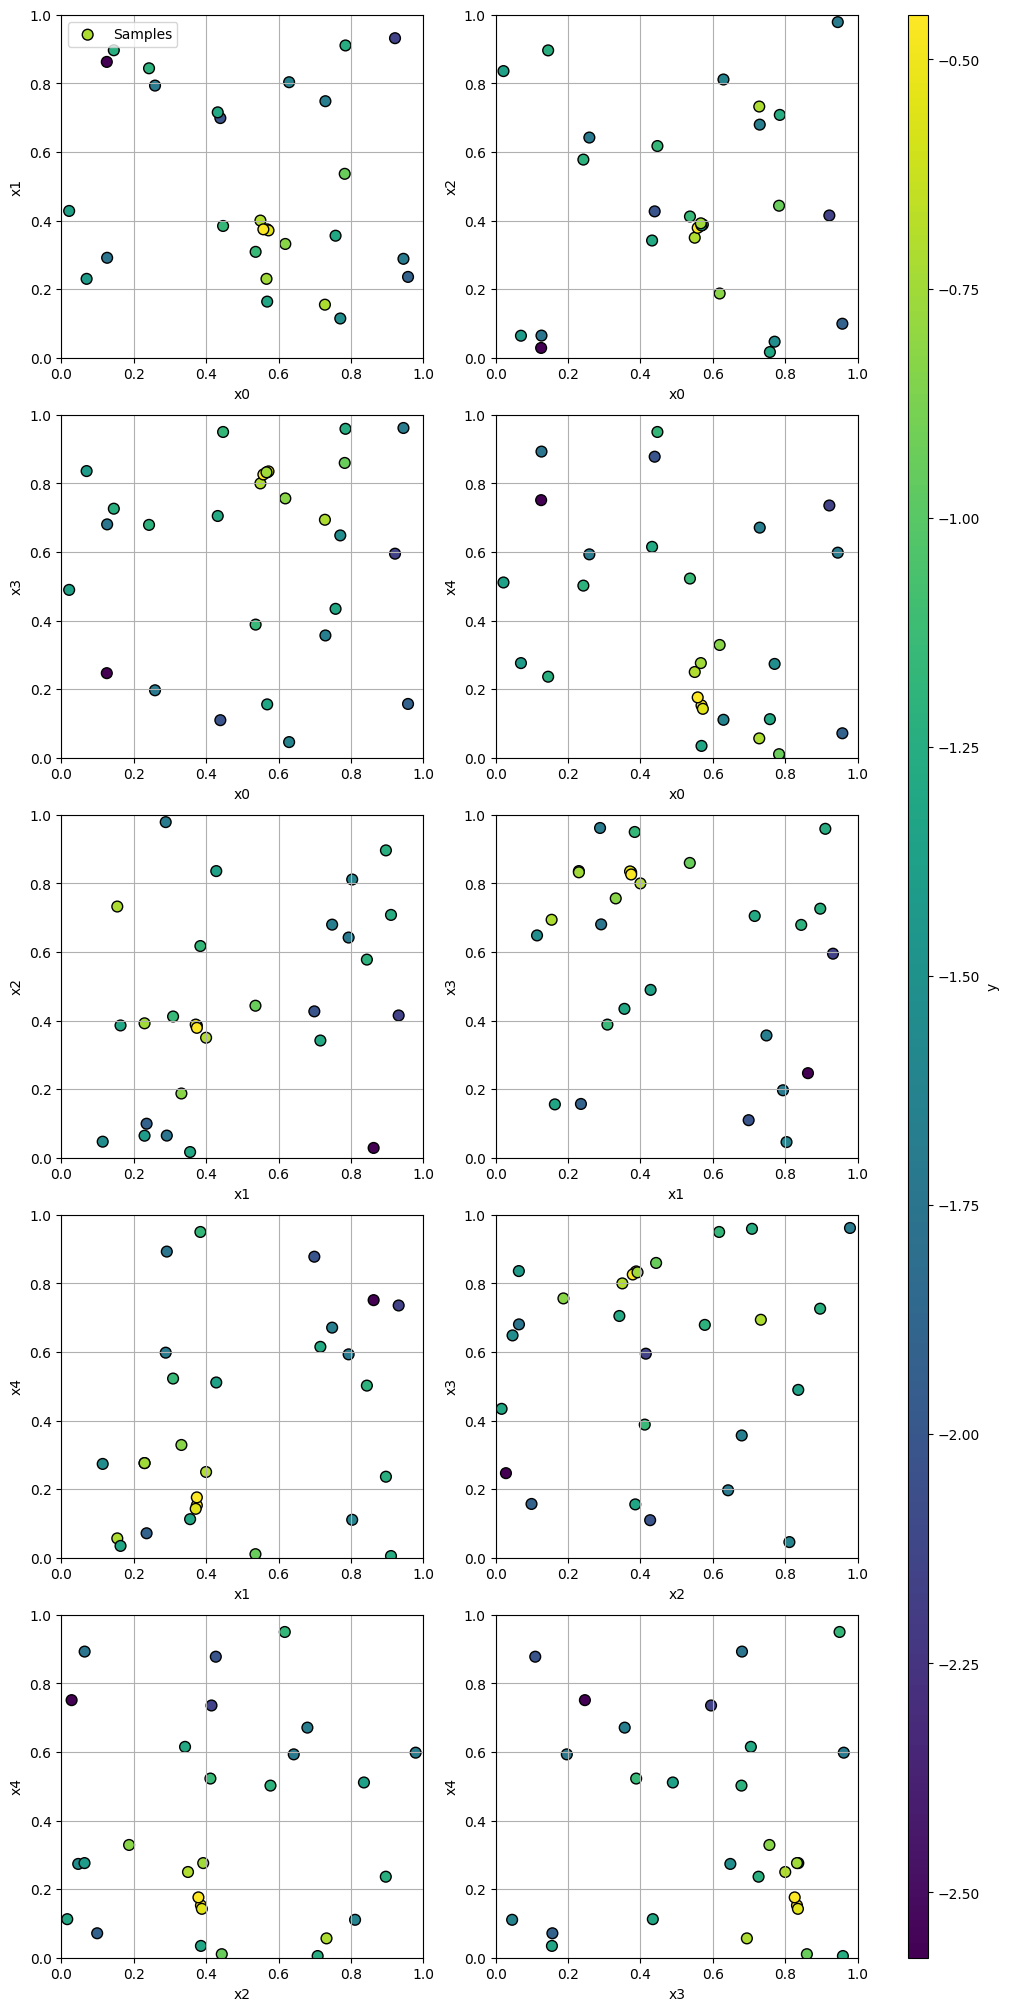

In [42]:
fig, axs = plot_2d_array(X, y)

From the above plots, last week's query has similar `x1`, `x2` and `x3` values as the best observed point. While it cannot be stated with certainty as data is quite sparse, it appears that the output may be more sensitive to changes in feature `x0` than previously thought.

We continue with an extra trees ensemble model using the Upper Confidence Bound (UCB) acquisition function to assess candidata points:

In [43]:
tree_model_params = {
    "n_estimators": 500,
    "max_depth": 5,
    "min_samples_leaf": 2,
    "seed_input": seed_input,
}

# Fit extremely randomised trees ensemble model
et = decision_trees.get_extra_trees_model(**tree_model_params)
et.fit(X, y)

# Perform grid search to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X_.ravel() for X_ in X_grid])
et_mean, et_std = decision_trees.get_ensemble_stats(et, X_pred)

# Extract best candidates from grid as those where Upper Confidence Bound (UCB)
# function is at maximum value and calculate centroid to find proposed point.
acq_func = acquisition.ucb(et_mean, et_std, k=1.96)
mask = np.isclose(acq_func, acq_func.max(), rtol=1e-6, atol=1e-9)
best_candidates = X_pred[mask]
x_next = best_candidates.mean(axis=0)
print(f"Proposed point from extra trees ensemble model = {x_next}")

# Use agglomerative clusterer to indicate whether best candidates are
# concentrated in a region or far apart
if len(best_candidates) < 2:
    labels = np.array([0])  # single cluster
else:
    clusterer = get_agglomerative_clusterer(n_dimensions=n_dimensions)
    labels = clusterer.fit_predict(best_candidates)
clusters, counts = np.unique(labels, return_counts=True)
res = 1.0 / grd_res

for cluster, count in zip(clusters, counts):
    print(f"Cluster {cluster}, counts = {count}")

    # Perform grid search for each cluster
    mask = labels == cluster
    cluster_candidates = best_candidates[mask]
    x_centre = cluster_candidates.mean(axis=0)
    bounds = [(max(0.0, x_ - res), min(1.0, x_ + res)) for x_ in x_centre]
    x_next = grid_search_mean(
        model=et,
        acq_func=acquisition.ucb,
        k=1.96,
        n_dimensions=n_dimensions,
        grd_res=grd_res,
        bounds=bounds,
    )
    print(f"Proposed point from cluster {cluster} = {x_next}")

Proposed point from extra trees ensemble model = [0.6  0.85 0.35 0.8  0.15]
Cluster 0, counts = 1
Proposed point from cluster 0 = [0.57309524 0.84928571 0.36833333 0.83261905 0.18738095]


The proposed point is similar last week's query. The only feature that is significantly different is `x1`, with a much larger value. The model suggests changing `x1` to see the effect of this single feature on the output in the promising region.

However, as we are now moving from a policy of exploration to one where we wish to understand the structure of the promising region where the best observed point lies, a random forests ensemble model may be a better choice. Unlike extra trees, split thresholds are selected according to observed data in random forests ensembles. This allows random forests ensemble models to respond more strongly to any new interactions between features that we may find:

In [44]:
tree_model_params = {
    "n_estimators": 500,
    "max_depth": 5,
    "min_samples_leaf": 2,
    "seed_input": seed_input,
}

# Fit extremely randomised trees ensemble model
rf = decision_trees.get_random_forests_model(**tree_model_params)
rf.fit(X, y)

# Perform grid search to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X_.ravel() for X_ in X_grid])
rf_mean, rf_std = decision_trees.get_ensemble_stats(rf, X_pred)

# Extract best candidates from grid as those where Upper Confidence Bound (UCB)
# function is at maximum value and calculate centroid to find proposed point.
acq_func = acquisition.ucb(rf_mean, rf_std, k=1.96)
mask = np.isclose(acq_func, acq_func.max(), rtol=1e-6, atol=1e-9)
best_candidates = X_pred[mask]
x_next = best_candidates.mean(axis=0)
print(f"Proposed point from random forests ensemble model = {x_next}")

# Use agglomerative clusterer to indicate whether best candidates are
# concentrated in a region or far apart
if len(best_candidates) < 2:
    labels = np.array([0])  # single cluster
else:
    clusterer = get_agglomerative_clusterer(n_dimensions=n_dimensions)
    labels = clusterer.fit_predict(best_candidates)
clusters, counts = np.unique(labels, return_counts=True)
res = 1.0 / grd_res

for cluster, count in zip(clusters, counts):
    print(f"Cluster {cluster}, counts = {count}")

    mask = labels == cluster
    cluster_candidates = best_candidates[mask]
    x_centre = cluster_candidates.mean(axis=0)
    bounds = [(max(0.0, x_ - res), min(1.0, x_ + res)) for x_ in x_centre]
    x_next = grid_search_mean(
        model=rf,
        acq_func=acquisition.ucb,
        k=1.96,
        n_dimensions=n_dimensions,
        grd_res=grd_res,
        bounds=bounds,
    )
    print(f"Proposed point from cluster {cluster} = {x_next}")

Proposed point from random forests ensemble model = [0.55  0.95  0.4   0.8   0.875]
Cluster 0, counts = 18
Proposed point from cluster 0 = [0.55416667 0.94940476 0.38511905 0.82321429 0.87440476]


Both the `x1` and `x4` features are significantly different from last week's query. This allows us to investigate whether changes in the `x1`-`x4` plane affect the output.

Because of differences in the random seed between the original analysis and that presented here, the point (0.5692, 0.93, 0.3844, 0.822, 0.794) was submitted as this week's query. Although there is a small difference between the proposed and submitted points, both attempt to answer the question of how changes in the `x1`-`x4` plane affect the output in this promising region.

## Week 10 - Keeping `x1` and `x4` in the promising region

In [45]:
import numpy as np

from bbo import acquisition, decision_trees
from bbo.clustering import get_agglomerative_clusterer
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.utils import construct_meshgrid, grid_search_mean

seed_input = "function 6"  # input string to create random seed
n_dimensions = 5  # number of features
grd_res = 21  # axis resolution

In [46]:
X, y = get_current_weeks_points(function_id=6, week=10)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.5692 0.93   0.3844 0.822  0.794 ] yields -1.7185685583006276


The output from last week's query is significantly lower than that of the best observed point. This is an indication that the output may be sensitive to simultaneous changes in the `x1`-`x4` plane.

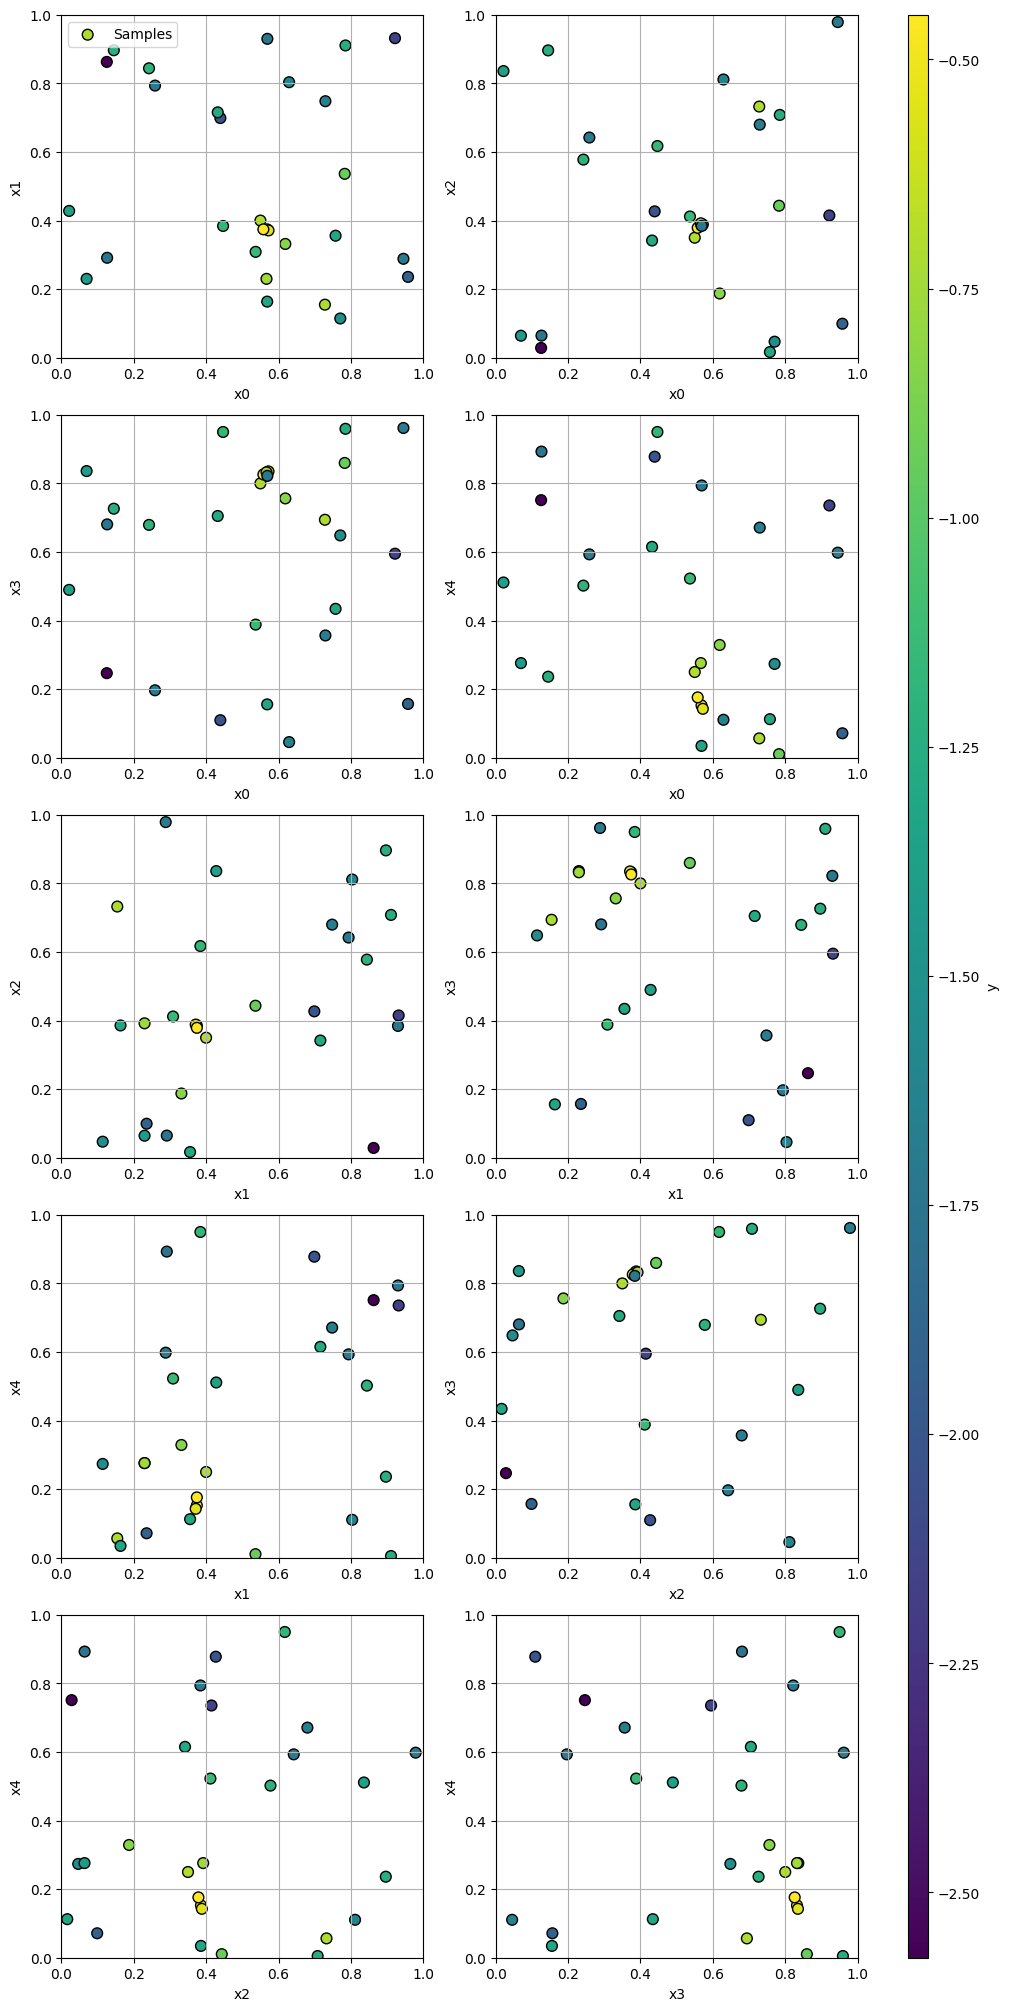

In [47]:
fig, axs = plot_2d_array(X, y)

We continue to construct a random forests ensemble model and perform a recursive grid search around the mean of the candidate points that maximise the Upper Confidence Bound (UCB) acquisition function:

In [48]:
tree_model_params = {
    "n_estimators": 500,
    "max_depth": 5,
    "min_samples_leaf": 2,
    "seed_input": seed_input,
}

# Fit extremely randomised trees ensemble model
rf = decision_trees.get_random_forests_model(**tree_model_params)
rf.fit(X, y)

# Perform grid search to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X_.ravel() for X_ in X_grid])
rf_mean, rf_std = decision_trees.get_ensemble_stats(rf, X_pred)

# Extract best candidates from grid as those where Upper Confidence Bound (UCB)
# function is at maximum value and calculate centroid to find proposed point.
acq_func = acquisition.ucb(rf_mean, rf_std, k=1.96)
mask = np.isclose(acq_func, acq_func.max(), rtol=1e-6, atol=1e-9)
best_candidates = X_pred[mask]
x_next = best_candidates.mean(axis=0)
print(f"Proposed point from random forests ensemble model = {x_next}")

# Use agglomerative clusterer to indicate whether best candidates are
# concentrated in a region or far apart
if len(best_candidates) < 2:
    labels = np.array([0])  # single cluster
else:
    clusterer = get_agglomerative_clusterer(n_dimensions=n_dimensions)
    labels = clusterer.fit_predict(best_candidates)
clusters, counts = np.unique(labels, return_counts=True)
res = 1.0 / grd_res

for cluster, count in zip(clusters, counts):
    print(f"Cluster {cluster}, counts = {count}")

    mask = labels == cluster
    cluster_candidates = best_candidates[mask]
    x_centre = cluster_candidates.mean(axis=0)
    bounds = [(max(0.0, x_ - res), min(1.0, x_ + res)) for x_ in x_centre]
    x_next = grid_search_mean(
        model=rf,
        acq_func=acquisition.ucb,
        k=1.96,
        n_dimensions=n_dimensions,
        grd_res=grd_res,
        bounds=bounds,
    )
    print(f"Proposed point from cluster {cluster} = {x_next}")

Proposed point from random forests ensemble model = [0.95 0.4  0.1  0.8  0.2 ]
Cluster 0, counts = 3
Proposed point from cluster 0 = [0.95       0.37619048 0.0952381  0.82142857 0.19761905]


The proposed point holds the `x1` and `x4` features in the promising region and varies the other dimensions, effectively testing for the opposite of last week's query. In other words, determining whether the output is relatively insensitive to simultaneous variations in `x0`, `x2` and `x3` if `x1` and `x4` are kept in the promising region.

As in previous weeks, initialising the random forests ensemble model resulted in a different point (0.93, 0.37864, 0.134, 0.8252, 0.198). The submitted and proposed points lie very close to each other and both attempt to answer the aforementioned question.

## Week 11 - A return to exploitation

In [49]:
import numpy as np

from bbo import acquisition, decision_trees
from bbo.bayesian_optimisation import get_reg_model
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array, plot_decision_tree
from bbo.random import sample_regions

seed_input = "function 6"  # input string to create random seed
n_dimensions = 5  # number of features
grd_res = 21  # axis resolution

In [50]:
X, y = get_current_weeks_points(function_id=6, week=11)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.93    0.37864 0.134   0.8252  0.198  ] yields -1.2642345817893283


While an improvement on the output from the previous week, last week's query still yields a relatively low output. Combined with our previous results, this suggests that the output in the promising region may be sensitive to changes in all dimensions. It would be difficult to reach a more decisive conclusion given the relatively small number of data points we have.

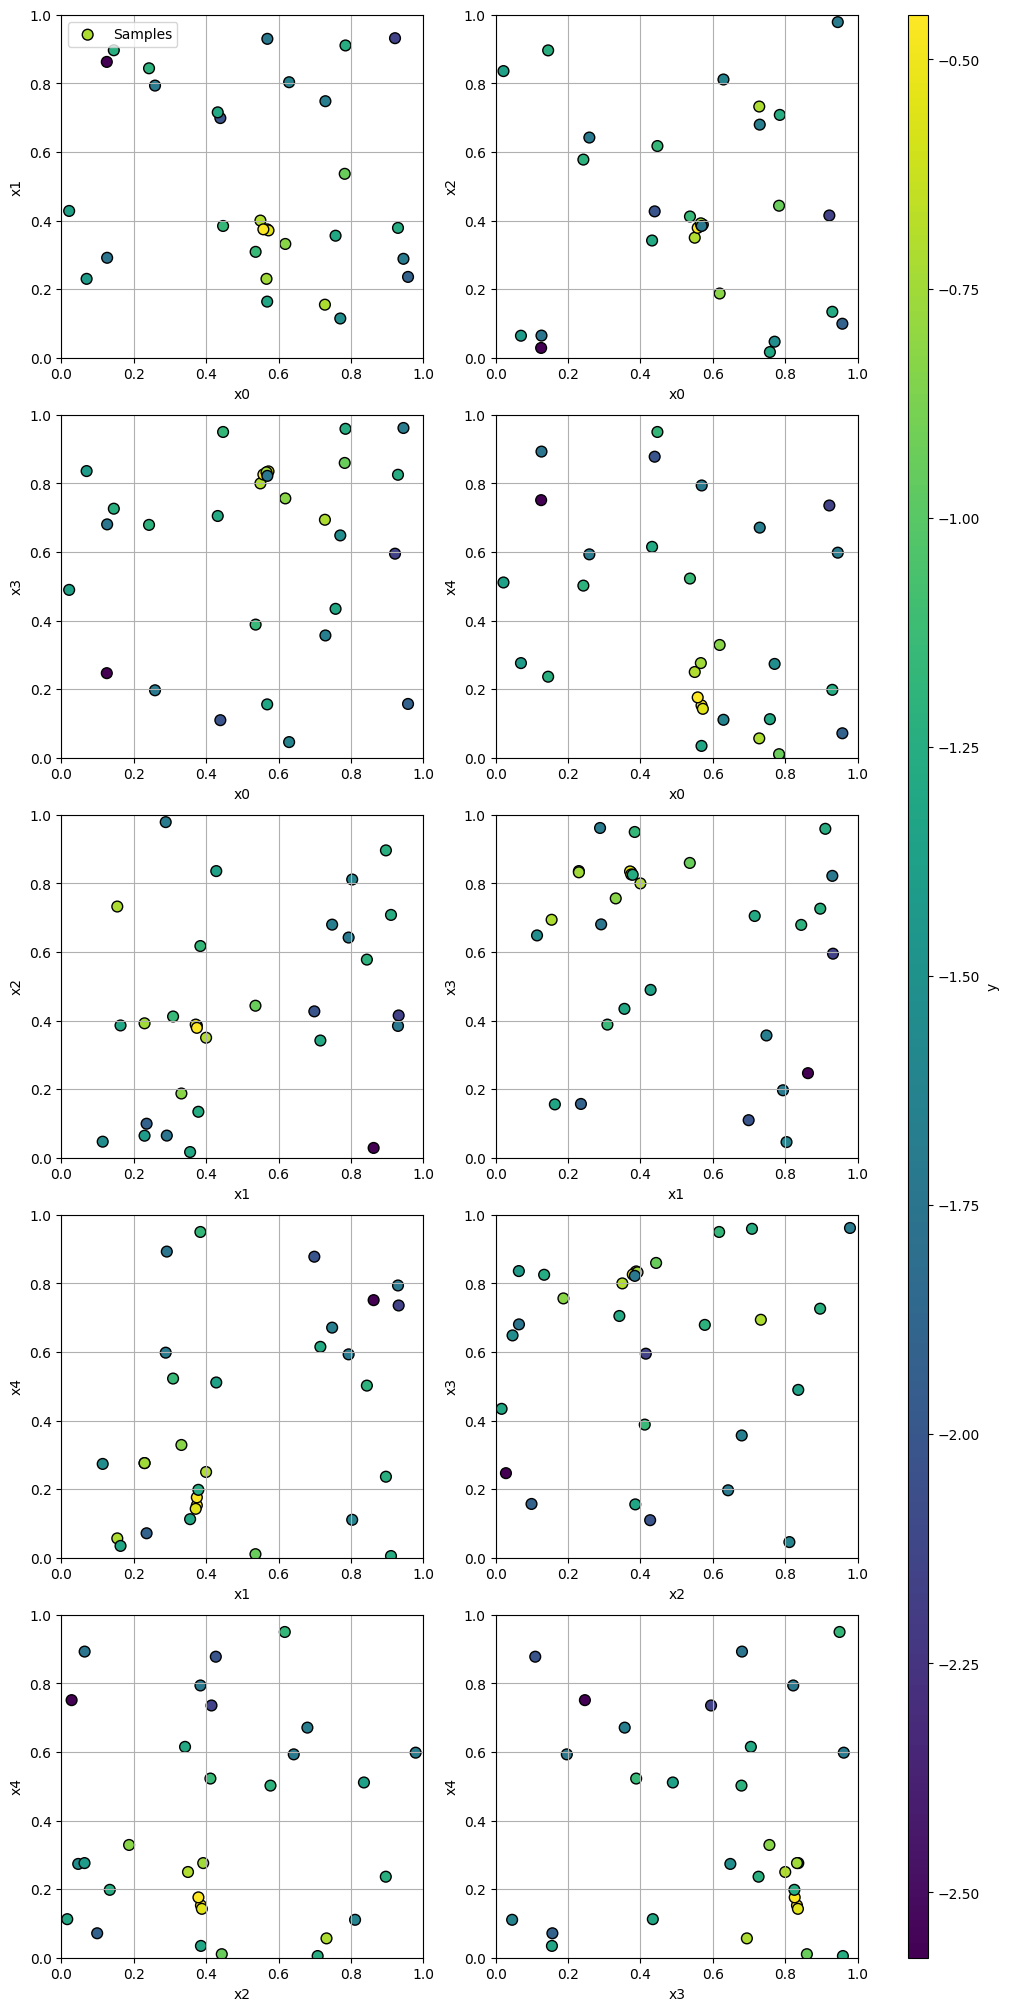

In [51]:
fig, axs = plot_2d_array(X, y)

While we can continue to hold a combination of features constant while varying others, this would require $2^{5} - 1 = 31$ queries to cover every combination. We simply do not have the required budget for this.

A better use of the remaining budget is a return to exploitation in the promising region we identified. We can return to Bayesian Optimisation with a Gaussian Process surrogate model, with which we started our analysis. To shift our focus to exploitation, we can assess candidates with an exploitative acquisition function such as Expected Improvement (EI) with a relatively small exploration parameter $\xi$.

Rather than use a grid search across the entire domain, which is hampered by the relatively poor grid resolution, we can use a random search to obtain candidate points to assess. To improve the proportion of promising candidate points, we can use a decision tree model to split the domain into regions and then sample from these regions according to the mean output from points in those regions. In other words, regions with a higher mean output, or in other words `value` in the decision tree diagram below, will have a greater concetration of candidate points. We can accomplish this by sampling candidates according to a softmax distribution using a relatively conservative sharpness parameter of 0.7:

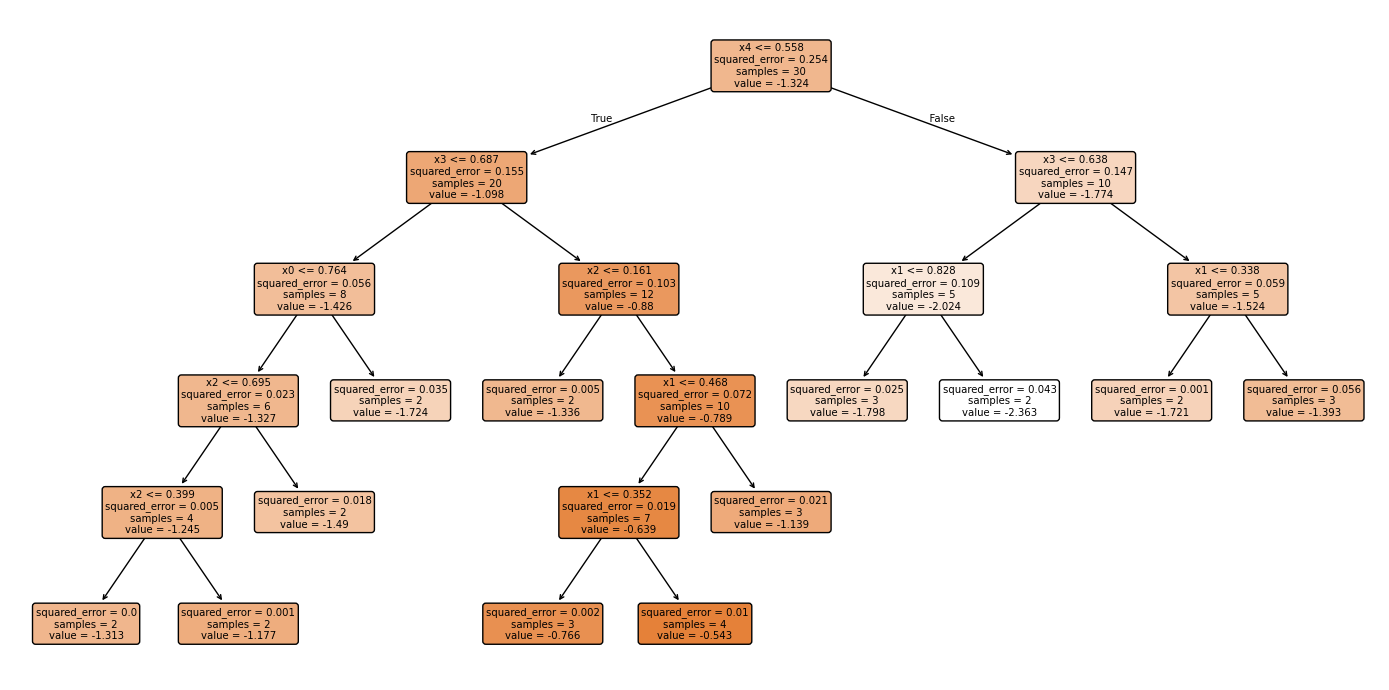

In [52]:
tree = decision_trees.get_decision_tree(
    max_depth=5, min_samples_leaf=2, seed_input=seed_input
)
tree.fit(X, y)

fig, ax = plot_decision_tree(tree=tree, n_dimensions=n_dimensions)

In [53]:
# Get leaf nodes and ranges
regions = decision_trees.get_regions(tree, n_dimensions)

# Generate candidates
n_samples = 2000  # number of candidates to generate
temperature = 0.7  # sharpness parameter for softmax distribution (lower values concentrate samples in more promising regions)
X_candidates, X_regions = sample_regions(
    n_samples, regions, seed_input, temperature
)

# Fit Gaussian Process surrogate model with RBF kernel and initial length
# scales of 0.1 in each dimension
gp_model = get_reg_model(
    n_dimensions=n_dimensions,
    seed_input=seed_input,
    length_scale_bounds=(1e-2, 100),
)
gp_model.fit(X, y)

length_scales = gp_model.kernel_.length_scale
print(f"Length scales: {length_scales}")

# Use Expected Improvement (EI) acquisition function to assess candidates
mean, std = gp_model.predict(X_candidates, return_std=True)
y_max = y.max()
acq_func = acquisition.expect_improv(mean, std, y_max=y_max, xi=0.01)
max_idx = np.argmax(acq_func)
x_next = X_candidates[max_idx]
print(f"Proposed point using Expected Improvment (xi = 0.01) acquisition function = {x_next}")
print(f"Distance between proposed point and nearest neighbour = {np.min(np.linalg.norm(X - x_next, axis=1))}")

Length scales: [6.87269293e+01 1.82741343e-02 1.63520066e-01 3.08626472e-01
 1.02088333e+01]
Proposed point using Expected Improvment (xi = 0.01) acquisition function = [0.53922135 0.38685244 0.3799803  0.94391597 0.04195947]
Distance between proposed point and nearest neighbour = 0.15297538517823075


We set the exploration parameter $\xi$ to the relatively small value of 0.01 and obtain a proposed point that lies a little outside the promising region in the `x3`-`x4` plane. Compared with the values we were getting with the Upper Confidence Bound (UCB) acquistiion function and recirsive grid search in previous weeks, the perturbations in this plane are relatively small. We expect this with a smaller exploration parameter as the EI acquisition function favours candidates with a high predicted output over those with high uncertainty.

## Week 12 - A return to random forests

In [54]:
import numpy as np

from bbo import acquisition, decision_trees
from bbo.clustering import get_agglomerative_clusterer
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.utils import construct_meshgrid, grid_search_mean

seed_input = "function 6"  # input string to create random seed
n_dimensions = 5  # number of features
grd_res = 21  # axis resolution

In [55]:
X, y = get_current_weeks_points(function_id=6, week=12)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.539221 0.386852 0.37998  0.943916 0.041959] yields -0.6535004187182505


Last week's query yields a relatively high output, although shy of that from the best observed point. We have a promising region that we can continue to exploit.

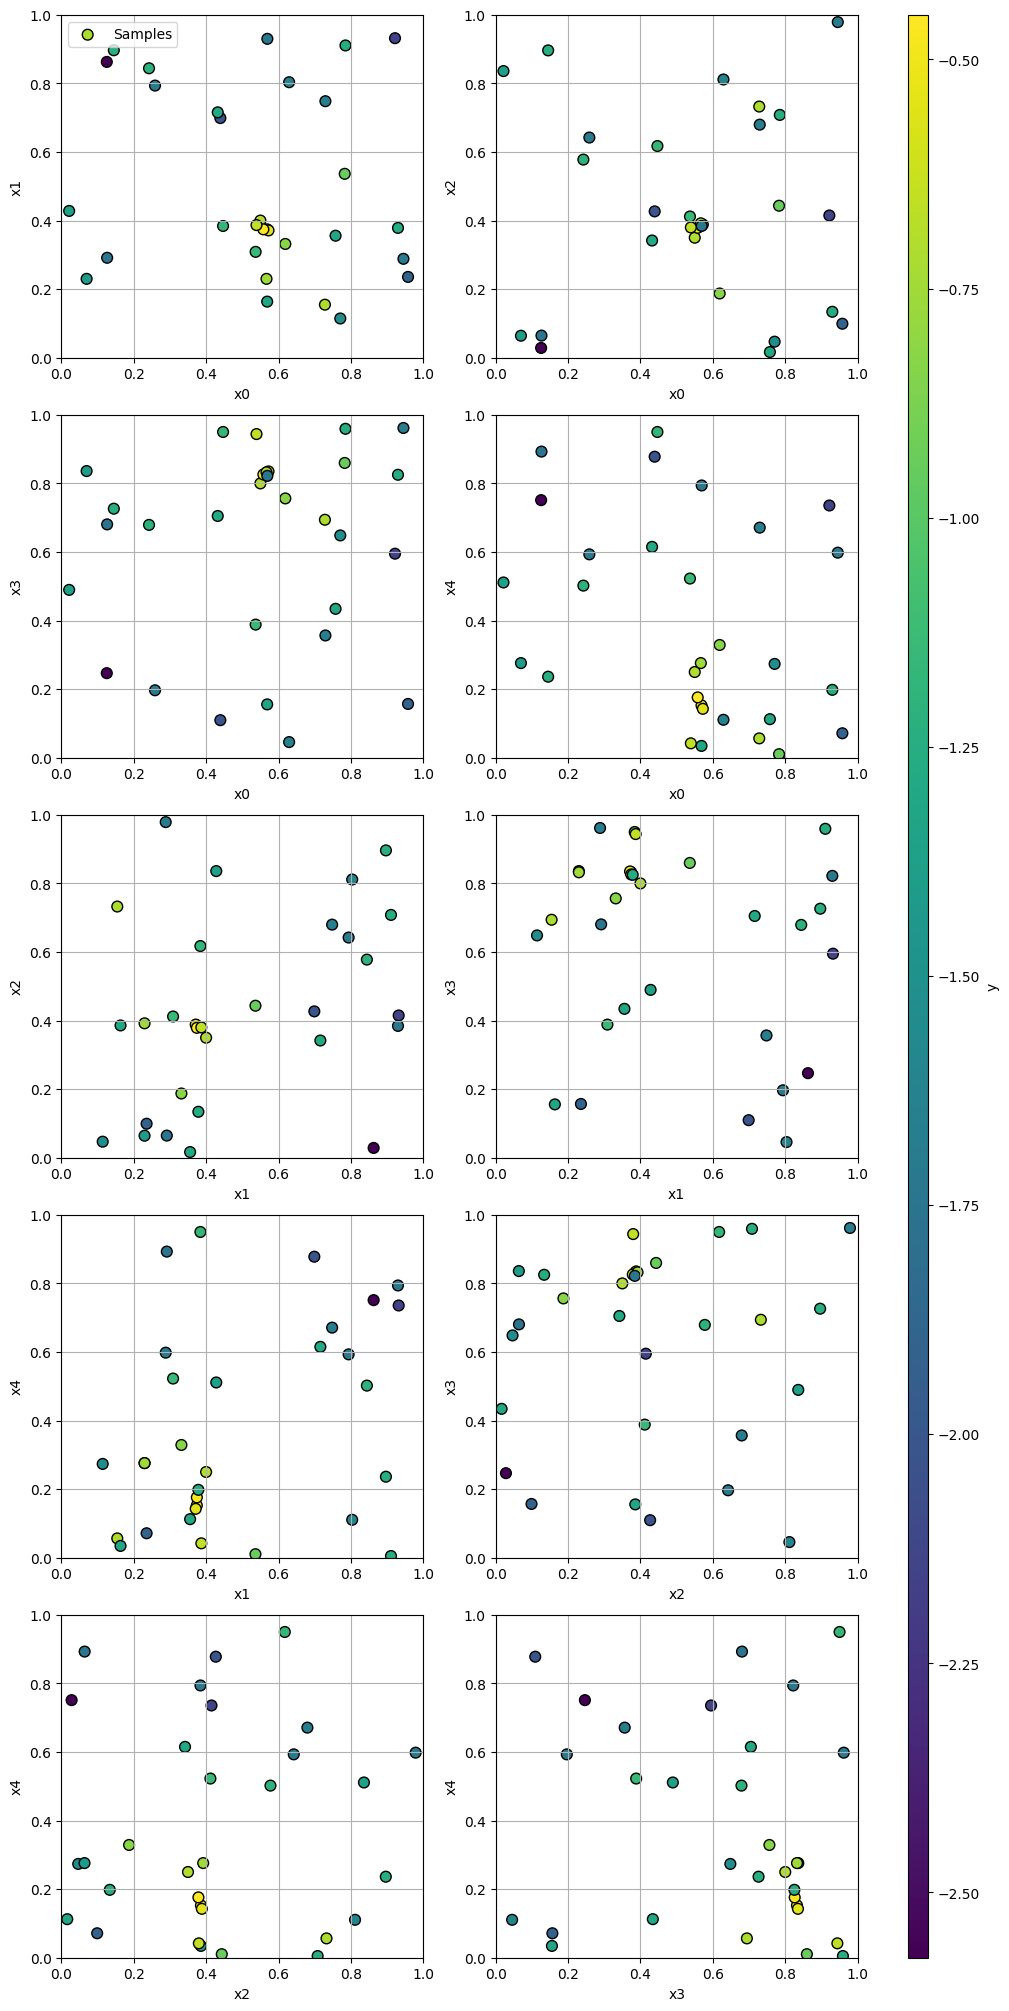

In [56]:
fig, axs = plot_2d_array(X, y)

As the output of a Gaussian Process surrogate model is sensitive to the choice of kernel, and given that our current dataset is too small relative to the dimensionality of the domain for us to determine which kernel would best fit the underlying function, we can train a random forests ensemble model instead. We adopt a recursive grid search to find the best candidate to query. Given that we only have 2 more queries left, the candidates are assessed by the more exploitative Probability of Improvement (PI) acquisition function:

In [57]:
tree_model_params = {
    "n_estimators": 500,
    "max_depth": 5,
    "min_samples_leaf": 2,
    "seed_input": seed_input,
}

# Fit extremely randomised trees ensemble model
rf = decision_trees.get_random_forests_model(**tree_model_params)
rf.fit(X, y)

# Perform grid search to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X_.ravel() for X_ in X_grid])
rf_mean, rf_std = decision_trees.get_ensemble_stats(rf, X_pred)

# Extract best candidates from grid as those where Probability of Improvement
# (PI) function is at maximum value and calculate centroid to find proposed
# point.
y_max = y.max()
acq_func = acquisition.prob_improv(rf_mean, rf_std, y_max=y_max)
mask = np.isclose(acq_func, acq_func.max(), rtol=1e-6, atol=1e-9)
best_candidates = X_pred[mask]
x_next = best_candidates.mean(axis=0)
print(f"Proposed point from random forests ensemble model = {x_next}")

# Use agglomerative clusterer to indicate whether best candidates are
# concentrated in a region or far apart
if len(best_candidates) < 2:
    labels = np.array([0])  # single cluster
else:
    clusterer = get_agglomerative_clusterer(n_dimensions=n_dimensions)
    labels = clusterer.fit_predict(best_candidates)

clusters, counts = np.unique(labels, return_counts=True)
res = 1.0 / grd_res
for cluster, count in zip(clusters, counts):
    print(f"Cluster {cluster}, counts = {count}")

    mask = labels == cluster
    cluster_candidates = best_candidates[mask]
    x_centre = cluster_candidates.mean(axis=0)
    bounds = [(max(0.0, x_ - res), min(1.0, x_ + res)) for x_ in x_centre]
    x_next = grid_search_mean(
        model=rf,
        acq_func=acquisition.prob_improv,
        y_max=y_max,
        n_dimensions=n_dimensions,
        grd_res=grd_res,
        bounds=bounds,
    )
    print(f"Proposed point from cluster {cluster} = {x_next}")

Proposed point from random forests ensemble model = [0.55  0.125 0.35  0.925 0.15 ]
Cluster 0, counts = 24
Proposed point from cluster 0 = [0.55666667 0.12452381 0.3852381  0.92452381 0.17333333]


As explained above, because the random seed used to initialise the random forests ensemble model was different to the one used here, a different point to the proposed one was submitted: (0.102, 0.22, 0.38352, 0.828795, 0.1788). The values for `x0`, `x1` and `x3` are significantly different between the submitted and proposed points. In the case of the former, the values for `x2`, `x3` and `x4` are consistent with the promising region we are currently exploiting.

Given the difference between these points, we can conclude that the random forests ensemble model is not stable. This is likely because of the small dataset relative to the number of dimensions, which can mean that small modelling differences between ensembles generated with different random seeds are amplified rather than averaged out.

Had the proposed point above been suggested during the original analysis, it is likely that we would have returned to the Gaussian Process surrogate model to find a new point to query (albeit using a PI acquisition function to assess the candidate points).

The submitted point allows us to investigate the effects of perturbations along the `x0` and `x1` dimesions. The relatively large distance from the promising region along `x0` adds an element of exploration to the query.

## Week 13 - Final attempt to find a new maximum

In [58]:
import numpy as np

from bbo import acquisition, decision_trees
from bbo.clustering import get_agglomerative_clusterer
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_array
from bbo.utils import construct_meshgrid, grid_search_mean

seed_input = "function 6"  # input string to create random seed
n_dimensions = 5  # number of features
grd_res = 21  # axis resolution

In [59]:
X, y = get_current_weeks_points(function_id=6, week=13)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.102    0.22     0.38352  0.828795 0.1788  ] yields -0.9845104521046606


Last week's query results in a lower output. This is probably a result of the large deviation in `x0` from the promising region.

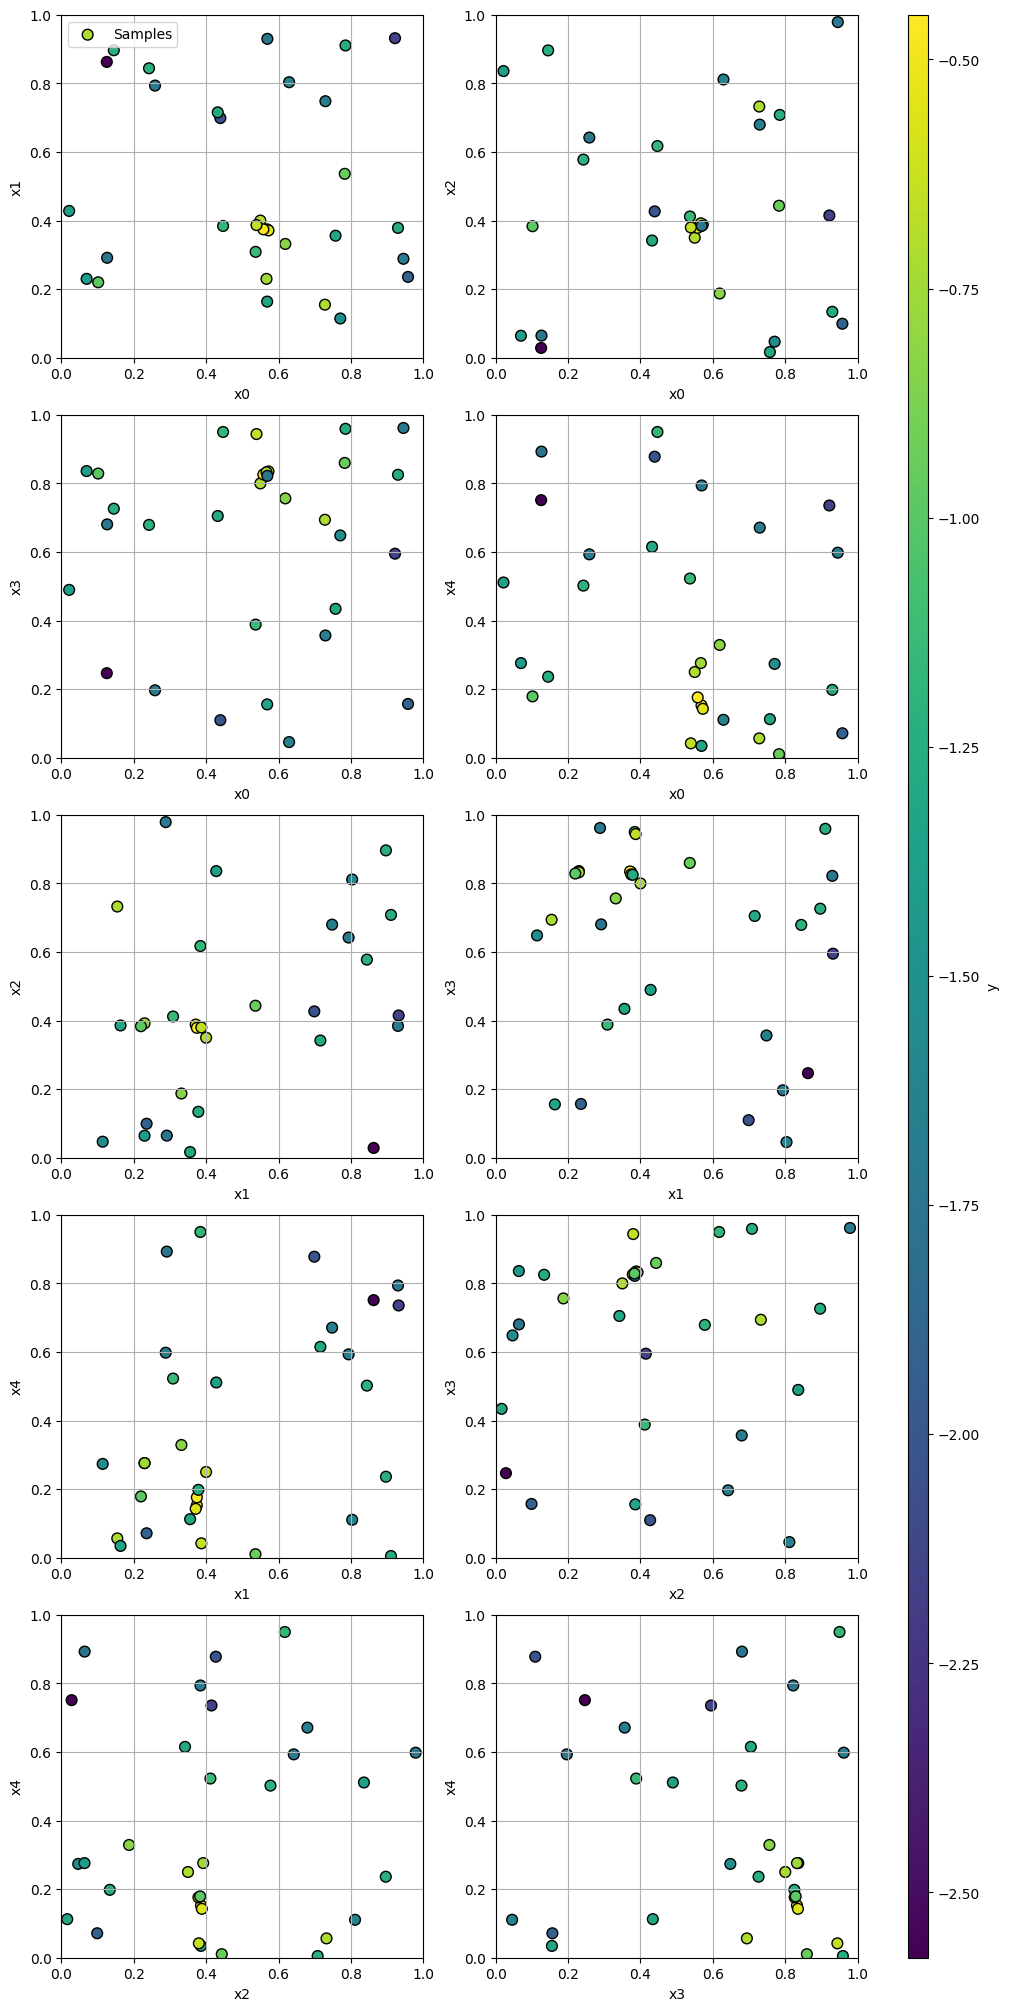

In [60]:
fig, axs = plot_2d_array(X, y)

As we had not discovered the instability of the the random forests ensemble model, for the final query we repeat our method from last week. We train a random forests ensemble model on the current dataset and use a Probability of Improvement (PI) acquisition function to assess candidates from a recursive grid search:

In [61]:
tree_model_params = {
    "n_estimators": 500,
    "max_depth": 5,
    "min_samples_leaf": 2,
    "seed_input": seed_input,
}

# Fit extremely randomised trees ensemble model
rf = decision_trees.get_random_forests_model(**tree_model_params)
rf.fit(X, y)

# Perform grid search to evaluate model output
X_grid = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X_.ravel() for X_ in X_grid])
rf_mean, rf_std = decision_trees.get_ensemble_stats(rf, X_pred)

# Extract best candidates from grid as those where Probability of Improvement
# (PI) function is at maximum value and calculate centroid to find proposed
# point.
y_max = y.max()
acq_func = acquisition.prob_improv(rf_mean, rf_std, y_max=y_max)
mask = np.isclose(acq_func, acq_func.max(), rtol=1e-6, atol=1e-9)
best_candidates = X_pred[mask]
x_next = best_candidates.mean(axis=0)
print(f"Proposed point from random forests ensemble model = {x_next}")

# Use agglomerative clusterer to indicate whether best candidates are
# concentrated in a region or far apart
if len(best_candidates) < 2:
    labels = np.array([0])  # single cluster
else:
    clusterer = get_agglomerative_clusterer(n_dimensions=n_dimensions)
    labels = clusterer.fit_predict(best_candidates)

clusters, counts = np.unique(labels, return_counts=True)
res = 1.0 / grd_res
for cluster, count in zip(clusters, counts):
    print(f"Cluster {cluster}, counts = {count}")

    mask = labels == cluster
    cluster_candidates = best_candidates[mask]
    x_centre = cluster_candidates.mean(axis=0)
    bounds = [(max(0.0, x_ - res), min(1.0, x_ + res)) for x_ in x_centre]
    x_next = grid_search_mean(
        model=rf,
        acq_func=acquisition.prob_improv,
        y_max=y_max,
        n_dimensions=n_dimensions,
        grd_res=grd_res,
        bounds=bounds,
    )
    print(f"Proposed point from cluster {cluster} = {x_next}")

Proposed point from random forests ensemble model = [0.65 0.4  0.35 0.8  0.15]
Cluster 0, counts = 1
Proposed point from cluster 0 = [0.62511905 0.37511905 0.3227381  0.8322619  0.15369048]


The proposed point appears to lie very close to the promising region, with a small pertubation in the `x0` direction. Because of a difference in random seeds during the initialisation of the random forests ensemble model, the point (0.578, 0.37576, 0.302, 0.990136, 0.16) was submitted as this week's query. The submitted point also lies very close to the promising region, except with a small perturbation in the `x3` direction.

Both points lie close to the promising region we have identified in this analysis. Therefore, despite the model instability that we have observed, both the proposed and submitted points are exploitative queries with the aim of refining the position of the local maximum.

## Final Result

In [62]:
from bbo.data import get_current_weeks_points, get_final_maximum
from bbo.plotting import plot_2d_array

X, y = get_current_weeks_points(function_id=6, week=14)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.578    0.37576  0.302    0.990136 0.16    ] yields -0.8115282873477868


Last week's query yields a slightly higher output showing us that we are moving in the correct direction. However, we do not find a new maximum.

The instability of the random forests model was not discovered until after the original analysis had been completed and all points had been submitted. Had it been discovered, we likely would have continued to use a region-based analysis with decision trees and Gaussian Process surrogate models as we did in week 11. The instability highlights the limitations of random forests ensemble models when data is sparse relative to the number of dimensions.

There were signs towards the end, however, that the stability of the random forests ensemble model was improving given the smaller difference between the proposed and submitted points during the final week. However, it may not have been the best use of limited queries, and Bayesian Optimisation with a Gaussian Process surrogate model had been efficient at exploiting the promising region during the first few weeks.

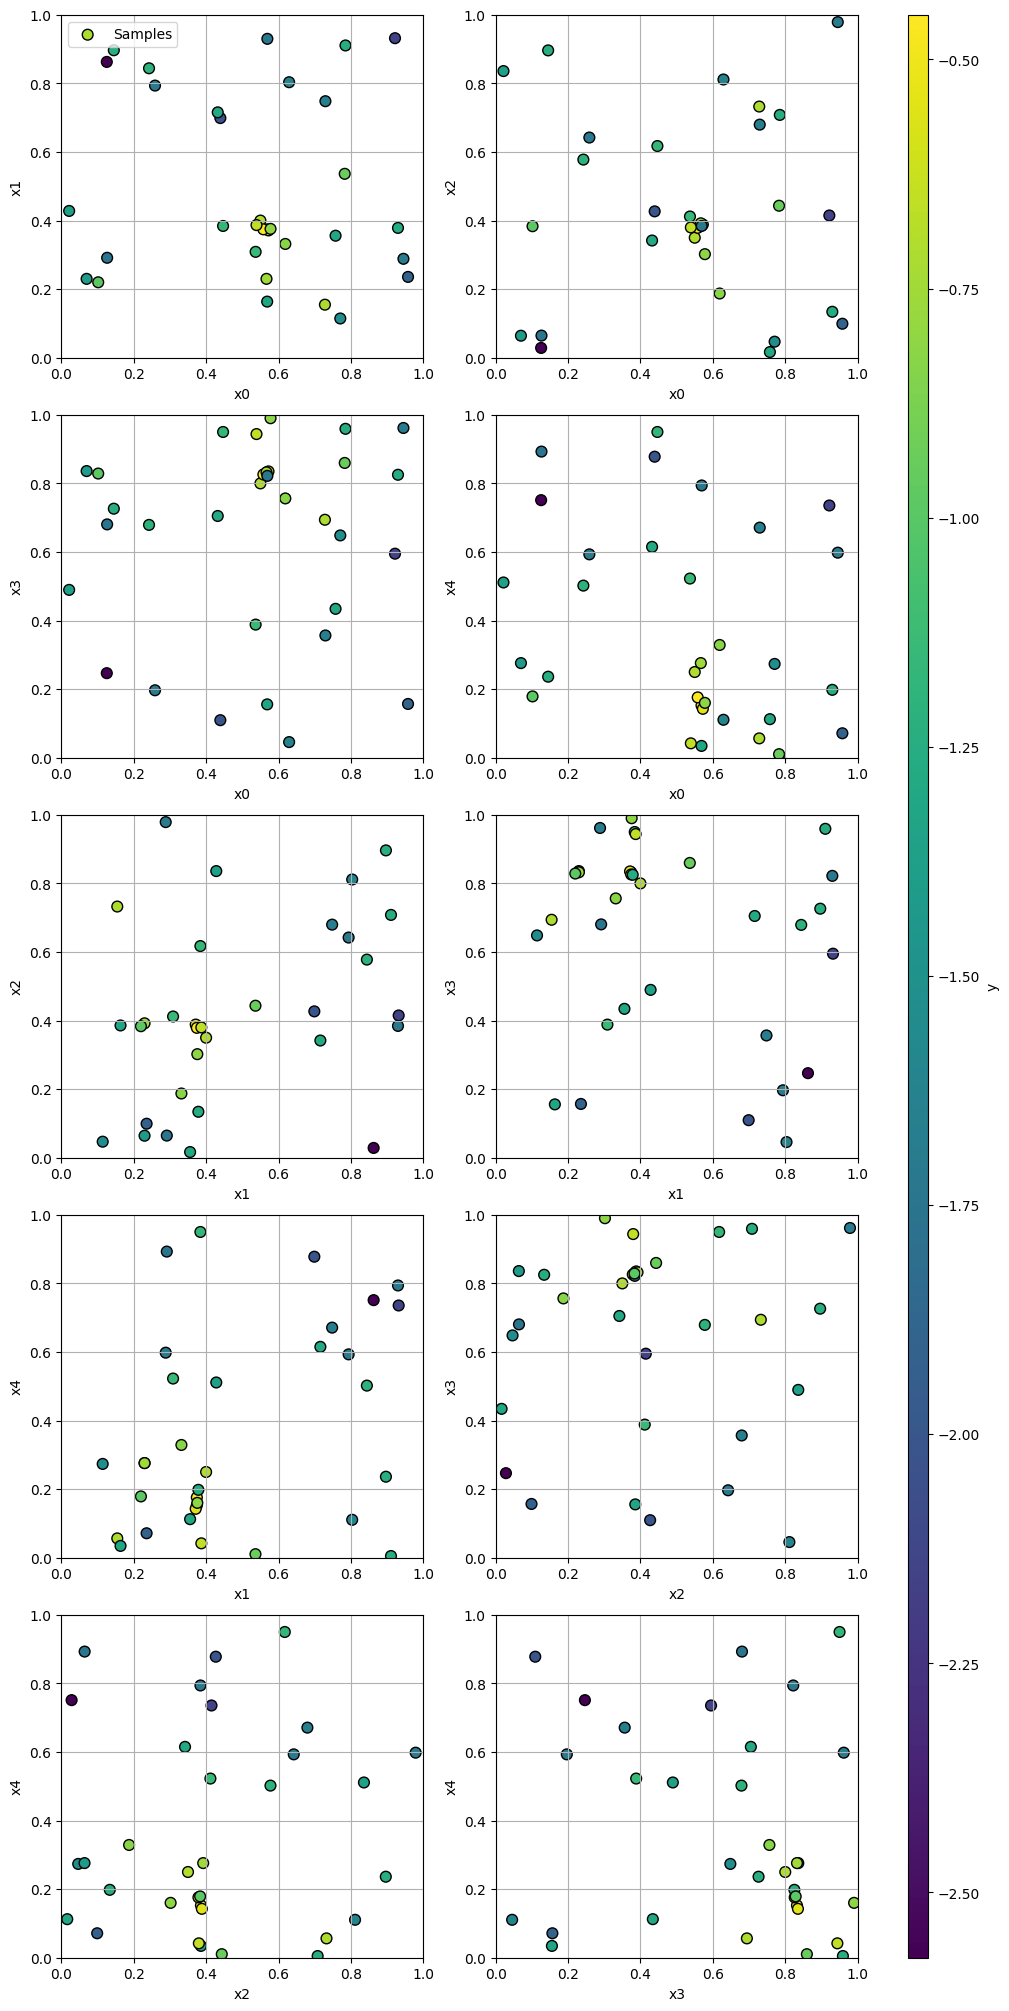

In [63]:
fig, axs = plot_2d_array(X, y)

The plots above show the promising region to lie in the space around (0.55, 0.4, 0.4, 0.8, 0.15). We identified no other promising regions.

Further work would be to exploit this region using Bayesian Optimisation with a Gaussian Process surrogate model. Rather than using a recursive grid search, we should adopt a region-based random search, where more candidates are generated in high-value regions that have been identified by a decision tree model. We only tried for one week, but the results were encouraging and the random search seems more efficient than a domain-wide grid search.

Another option would be to restrict the grid search to promising region. We would need to submit more queries to determine which would be more fruitful.

We found our best observed point relatively early on during the exploitation stage in week 2:

In [64]:
X_best, y_best, y_improv = get_final_maximum(function_id=6)
print(f"The best observed point {X_best} yields an output of {y_best}, which is an absolute improvement of {y_improv} over the best point in the initial data set")

The best observed point [0.5687   0.374362 0.38575  0.832375 0.152625] yields an output of -0.45127050312758443, which is an absolute improvement of 0.262994444692656 over the best point in the initial data set
